# Prepare data

## Signup date vs first order date

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

DATA_DIR_CANDIDATES = [
    Path("datathon"),
    Path("../datathon"),
    Path.cwd() / "datathon",
    Path.cwd().parent / "datathon",
]
DATA_DIR = next(path for path in DATA_DIR_CANDIDATES if (path / "orders.csv").exists())
DATA_DIR

WindowsPath('../datathon')

In [35]:
customers = pd.read_csv(
    DATA_DIR / "customers.csv",
    usecols=["customer_id", "signup_date", "acquisition_channel"],
    parse_dates=["signup_date"],
)

orders = pd.read_csv(
    DATA_DIR / "orders.csv",
    usecols=["order_id", "customer_id", "order_date"],
    parse_dates=["order_date"],
)

first_order_by_customer = (
    orders.groupby("customer_id", as_index=False)
    .agg(
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max"),
        order_count=("order_id", "count"),
    )
)

signup_first_order = customers.merge(first_order_by_customer, on="customer_id", how="inner")
signup_first_order["signup_minus_first_order_days"] = (
    signup_first_order["signup_date"] - signup_first_order["first_order_date"]
).dt.days
signup_first_order["signup_after_first_order"] = signup_first_order["signup_minus_first_order_days"] > 0
signup_first_order["signup_after_last_order"] = signup_first_order["signup_date"] > signup_first_order["last_order_date"]

summary = pd.DataFrame(
    {
        "customers_with_orders": [len(signup_first_order)],
        "signup_after_first_order_customers": [int(signup_first_order["signup_after_first_order"].sum())],
        "signup_after_first_order_pct": [signup_first_order["signup_after_first_order"].mean() * 100],
        "signup_after_last_order_customers": [int(signup_first_order["signup_after_last_order"].sum())],
        "signup_after_last_order_pct": [signup_first_order["signup_after_last_order"].mean() * 100],
        "median_signup_minus_first_order_days": [signup_first_order["signup_minus_first_order_days"].median()],
    }
)

display(summary.round(2))
display(
    signup_first_order["signup_minus_first_order_days"]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame("days")
    .round(2)
)

,customers_with_orders,signup_after_first_order_customers,signup_after_first_order_pct,signup_after_last_order_customers,signup_after_last_order_pct,median_signup_minus_first_order_days
0,90246,80623,89.34,41537,46.03,1839.0


,days
count,90246.00
mean,1678.02
std,1265.04
min,-3725.00
1%,-1770.55
5%,-632.00
10%,-54.00
25%,858.00
50%,1839.00
75%,2676.00


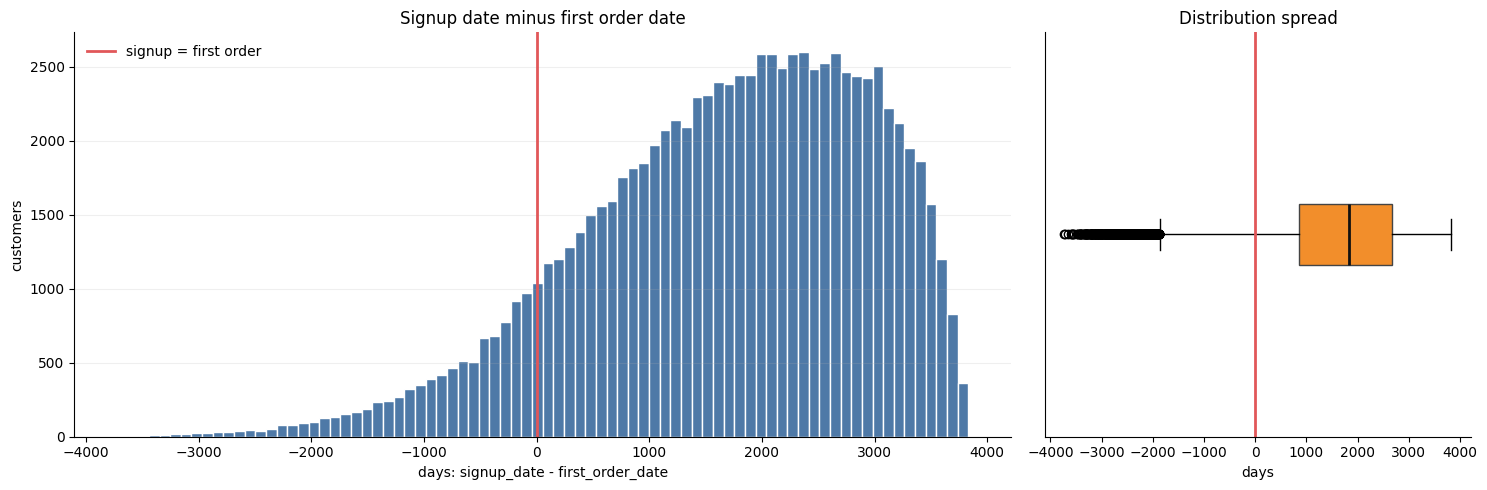

In [36]:
plot_data = signup_first_order.dropna(subset=["signup_minus_first_order_days"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [2.2, 1]})

axes[0].hist(plot_data["signup_minus_first_order_days"], bins=80, color="#4E79A7", edgecolor="white")
axes[0].axvline(0, color="#E15759", linewidth=2, label="signup = first order")
axes[0].set_title("Signup date minus first order date")
axes[0].set_xlabel("days: signup_date - first_order_date")
axes[0].set_ylabel("customers")
axes[0].legend(frameon=False)

axes[1].boxplot(
    plot_data["signup_minus_first_order_days"],
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#F28E2B", "edgecolor": "#444444"},
    medianprops={"color": "#111111", "linewidth": 2},
)
axes[1].axvline(0, color="#E15759", linewidth=2)
axes[1].set_title("Distribution spread")
axes[1].set_xlabel("days")
axes[1].set_yticks([])

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [37]:
bins = [-10_000, -365, -90, -30, -7, -1, 0, 1, 7, 30, 90, 180, 365, 730, 10_000]
labels = [
    "signup >= 1y before first order",
    "signup 91-365d before",
    "signup 31-90d before",
    "signup 8-30d before",
    "signup 1-7d before",
    "same day",
    "signup 1d after",
    "signup 2-7d after",
    "signup 8-30d after",
    "signup 31-90d after",
    "signup 91-180d after",
    "signup 181-365d after",
    "signup 366-730d after",
    "signup >730d after",
]

diff_bucket_summary = (
    plot_data.assign(
        signup_first_order_gap_bucket=pd.cut(
            plot_data["signup_minus_first_order_days"],
            bins=bins,
            labels=labels,
            include_lowest=True,
        )
    )
    .groupby("signup_first_order_gap_bucket", observed=False)
    .agg(customers=("customer_id", "count"), avg_orders_per_customer=("order_count", "mean"))
    .assign(customer_pct=lambda df: df["customers"] / df["customers"].sum() * 100)
    .reset_index()
)

display(diff_bucket_summary.round({"avg_orders_per_customer": 2, "customer_pct": 2}))

,signup_first_order_gap_bucket,customers,avg_orders_per_customer,customer_pct
0,signup >= 1y before first order,6210,1.70,6.88
1,signup 91-365d before,2445,2.97,2.71
2,signup 31-90d before,630,3.76,0.70
3,signup 8-30d before,256,3.93,0.28
4,signup 1-7d before,74,4.45,0.08
5,same day,8,1.75,0.01
6,signup 1d after,8,5.88,0.01
7,signup 2-7d after,59,3.14,0.07
8,signup 8-30d after,242,3.98,0.27
9,signup 31-90d after,729,4.00,0.81


## Định nghĩa metric Revenue, COGS và Profit

Quyết định sử dụng trong EDA này:

- Dùng `sales.Revenue` làm baseline **doanh thu gộp theo ngày**.
- Dùng `sales.COGS` làm baseline **giá vốn theo ngày**.
- Định nghĩa `gross_profit = Revenue - COGS` và `gross_margin_pct = gross_profit / Revenue` cho phân tích doanh thu/lợi nhuận theo ngày.
- Không dùng `payment_value` để thay thế trực tiếp cho `sales.Revenue`.
- Không xem `net_revenue = quantity * unit_price - discount_amount` là cùng một metric với `sales.Revenue`.
- Các tổng transaction sau khi lọc status, ví dụ delivered-only hoặc non-cancelled orders, được xem là một góc nhìn phân tích riêng chứ không phải định nghĩa của `sales.csv`.

Bằng chứng từ bước kiểm tra data quality:

- `sales.Revenue` khớp chính xác với all-order `gross_revenue = quantity * unit_price`, với `0` ngày bị lệch.
- `sales.COGS` khớp với all-order `calculated_cogs = quantity * products.cogs` trong sai số làm tròn, cũng với `0` ngày bị lệch.
- `sales.Revenue` khác `net_revenue` trên `1,707` ngày vì `sales.csv` lưu doanh thu gộp trước discount.
- `sales.Revenue` khác `payment_value` trên `1,707` ngày; `payment_value` đi theo giá trị net/discounted order value.
- `payment_value` khớp chính xác với `net_revenue`, với `0` order bị lệch và max absolute difference chỉ ở mức nhiễu floating-point.
- Các subset transaction theo status khác với `sales.csv`; điều này là expected vì `sales.csv` có vẻ được tạo từ **tất cả đơn hàng**.


## Aggregate `order_items` về grain `order_id + product_id`

Quyết định: không drop các dòng trùng `order_id + product_id`, vì các dòng này không phải exact duplicate. Cách xử lý đúng hơn là aggregate về grain cần dùng cho phân tích product-in-order.

Logic aggregate:

- `quantity`: cộng tổng.
- `gross_revenue`: cộng tổng `quantity * unit_price`.
- `discount_amount`: cộng tổng.
- `net_revenue`: `gross_revenue - discount_amount`.
- `weighted_unit_price`: `gross_revenue / quantity`, thay vì lấy trung bình đơn giản của `unit_price`.
- `line_count`: số dòng gốc được gom lại; nếu `line_count > 1` thì đó là nhóm từng bị duplicate theo candidate key.
- `promo_id`, `promo_id_2`: giữ giá trị non-null đầu tiên và số lượng giá trị unique để biết nhóm có nhiều promotion khác nhau hay không.

In [38]:
order_items_raw = pd.read_csv(DATA_DIR / "order_items.csv", low_memory=False)

order_items_prepared = order_items_raw.assign(
    gross_revenue=lambda df: df["quantity"] * df["unit_price"],
    net_revenue=lambda df: df["quantity"] * df["unit_price"] - df["discount_amount"],
)

order_product_items = (
    order_items_prepared.groupby(["order_id", "product_id"], as_index=False)
    .agg(
        line_count=("product_id", "size"),
        quantity=("quantity", "sum"),
        gross_revenue=("gross_revenue", "sum"),
        discount_amount=("discount_amount", "sum"),
        net_revenue=("net_revenue", "sum"),
        unit_price_min=("unit_price", "min"),
        unit_price_max=("unit_price", "max"),
        promo_id=("promo_id", "first"),
        promo_id_unique_count=("promo_id", "nunique"),
        promo_id_2=("promo_id_2", "first"),
        promo_id_2_unique_count=("promo_id_2", "nunique"),
    )
    .assign(
        weighted_unit_price=lambda df: df["gross_revenue"] / df["quantity"],
        has_multiple_lines=lambda df: df["line_count"] > 1,
        has_unit_price_variation=lambda df: df["unit_price_min"] != df["unit_price_max"],
        has_multiple_promos=lambda df: (df["promo_id_unique_count"] > 1) | (df["promo_id_2_unique_count"] > 1),
    )
)

order_product_items.head()

,order_id,product_id,line_count,quantity,gross_revenue,discount_amount,net_revenue,unit_price_min,unit_price_max,promo_id,promo_id_unique_count,promo_id_2,promo_id_2_unique_count,weighted_unit_price,has_multiple_lines,has_unit_price_variation,has_multiple_promos
0,1,2400,1,7,7967.54,0.0,7967.54,1138.22,1138.22,None,0,None,0,1138.22,False,False,False
1,2,609,1,7,71163.75,0.0,71163.75,10166.25,10166.25,None,0,None,0,10166.25,False,False,False
2,3,396,1,3,33660.99,0.0,33660.99,11220.33,11220.33,None,0,None,0,11220.33,False,False,False
3,4,635,1,5,53196.25,0.0,53196.25,10639.25,10639.25,None,0,None,0,10639.25,False,False,False
4,6,1935,1,1,1597.84,0.0,1597.84,1597.84,1597.84,None,0,None,0,1597.84,False,False,False


In [39]:
aggregation_validation = pd.DataFrame(
    {
        "metric": ["rows", "quantity", "gross_revenue", "discount_amount", "net_revenue"],
        "before_aggregation": [
            len(order_items_prepared),
            order_items_prepared["quantity"].sum(),
            order_items_prepared["gross_revenue"].sum(),
            order_items_prepared["discount_amount"].sum(),
            order_items_prepared["net_revenue"].sum(),
        ],
        "after_aggregation": [
            len(order_product_items),
            order_product_items["quantity"].sum(),
            order_product_items["gross_revenue"].sum(),
            order_product_items["discount_amount"].sum(),
            order_product_items["net_revenue"].sum(),
        ],
    }
)
aggregation_validation["difference"] = (
    aggregation_validation["after_aggregation"] - aggregation_validation["before_aggregation"]
)

display(aggregation_validation)
display(
    order_product_items.query("has_multiple_lines")
    .sort_values(["order_id", "product_id"])
    .head(20)
)

,metric,before_aggregation,after_aggregation,difference
0,rows,7.146690e+05,7.146530e+05,-16.000000
1,quantity,3.213143e+06,3.213143e+06,0.000000
2,gross_revenue,1.643048e+10,1.643048e+10,0.000000
3,discount_amount,7.496073e+08,7.496073e+08,0.000000
4,net_revenue,1.568087e+10,1.568087e+10,-0.000002


,order_id,product_id,line_count,quantity,gross_revenue,discount_amount,net_revenue,unit_price_min,unit_price_max,promo_id,promo_id_unique_count,promo_id_2,promo_id_2_unique_count,weighted_unit_price,has_multiple_lines,has_unit_price_variation,has_multiple_promos
12233,14280,976,2,3,11895.45,0.00,11895.45,3937.99,4019.47,None,0,None,0,3965.150000,True,True,False
99644,113379,786,2,7,4865.41,0.00,4865.41,694.34,699.37,None,0,None,0,695.058571,True,True,False
189237,215525,1859,2,10,18966.55,0.00,18966.55,1896.11,1897.20,None,0,None,0,1896.655000,True,True,False
190288,216740,791,2,13,10472.40,0.00,10472.40,793.10,825.52,None,0,None,0,805.569231,True,True,False
214307,243342,777,2,12,14004.24,2800.85,11203.39,1147.21,1181.17,PROMO-0010,1,None,0,1167.020000,True,True,False
233631,265263,2394,2,13,18172.90,2180.75,15992.15,1394.97,1400.44,PROMO-0011,1,None,0,1397.915385,True,True,False
347480,397622,2045,2,14,78577.88,0.00,78577.88,5583.62,5634.52,None,0,None,0,5612.705714,True,True,False
348155,398385,2016,2,15,56217.03,0.00,56217.03,3684.49,3803.20,None,0,None,0,3747.802000,True,True,False
373190,428208,2090,2,6,25919.26,0.00,25919.26,4302.56,4354.51,None,0,None,0,4319.876667,True,True,False
460546,530051,2219,2,9,15648.97,0.00,15648.97,1732.28,1743.97,None,0,None,0,1738.774444,True,True,False


# Exploratory Data Analysis

## 1. Target overview: Revenue

Mục tiêu của phần này:

- Kiểm tra date range của train (`sales.csv`) và forecast horizon (`sample_submission.csv`).
- Tóm tắt phân phối target `Revenue`.
- Vẽ chuỗi thời gian doanh thu theo ngày.
- Vẽ histogram và log-histogram để nhìn độ lệch/phân phối đuôi dài.
- Flag các ngày doanh thu cao/thấp bất thường bằng IQR để review trong EDA, không tự động loại bỏ.

In [40]:
import numpy as np

sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"]).sort_values("Date")
sample_submission = pd.read_csv(
    DATA_DIR / "sample_submission.csv",
    parse_dates=["Date"],
).sort_values("Date")

sales["gross_profit"] = sales["Revenue"] - sales["COGS"]
sales["gross_margin_pct"] = sales["gross_profit"] / sales["Revenue"]

train_calendar_days = (sales["Date"].max() - sales["Date"].min()).days + 1
test_calendar_days = (sample_submission["Date"].max() - sample_submission["Date"].min()).days + 1
forecast_gap_days = (sample_submission["Date"].min() - sales["Date"].max()).days

target_date_summary = pd.DataFrame(
    {
        "dataset": ["train_sales", "forecast_horizon"],
        "start_date": [sales["Date"].min(), sample_submission["Date"].min()],
        "end_date": [sales["Date"].max(), sample_submission["Date"].max()],
        "rows": [len(sales), len(sample_submission)],
        "calendar_days": [train_calendar_days, test_calendar_days],
        "missing_calendar_days": [train_calendar_days - len(sales), test_calendar_days - len(sample_submission)],
    }
)

display(target_date_summary)
print(f"Gap từ ngày train cuối đến ngày forecast đầu tiên: {forecast_gap_days} ngày")

,dataset,start_date,end_date,rows,calendar_days,missing_calendar_days
0,train_sales,2012-07-04,2022-12-31,3833,3833,0
1,forecast_horizon,2023-01-01,2024-07-01,548,548,0


Gap từ ngày train cuối đến ngày forecast đầu tiên: 1 ngày


In [41]:
revenue_stats = (
    sales["Revenue"]
    .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame("Revenue")
)

extra_revenue_stats = pd.DataFrame(
    {
        "Revenue": {
            "missing": sales["Revenue"].isna().sum(),
            "zero_or_negative": (sales["Revenue"] <= 0).sum(),
            "skew": sales["Revenue"].skew(),
            "kurtosis": sales["Revenue"].kurtosis(),
        }
    }
)

display(pd.concat([revenue_stats, extra_revenue_stats]).round(2))

,Revenue
count,3833.00
mean,4286584.03
std,2624840.20
min,279813.94
1%,845078.75
5%,1352929.23
10%,1718265.35
25%,2471088.82
50%,3647303.90
75%,5350877.20


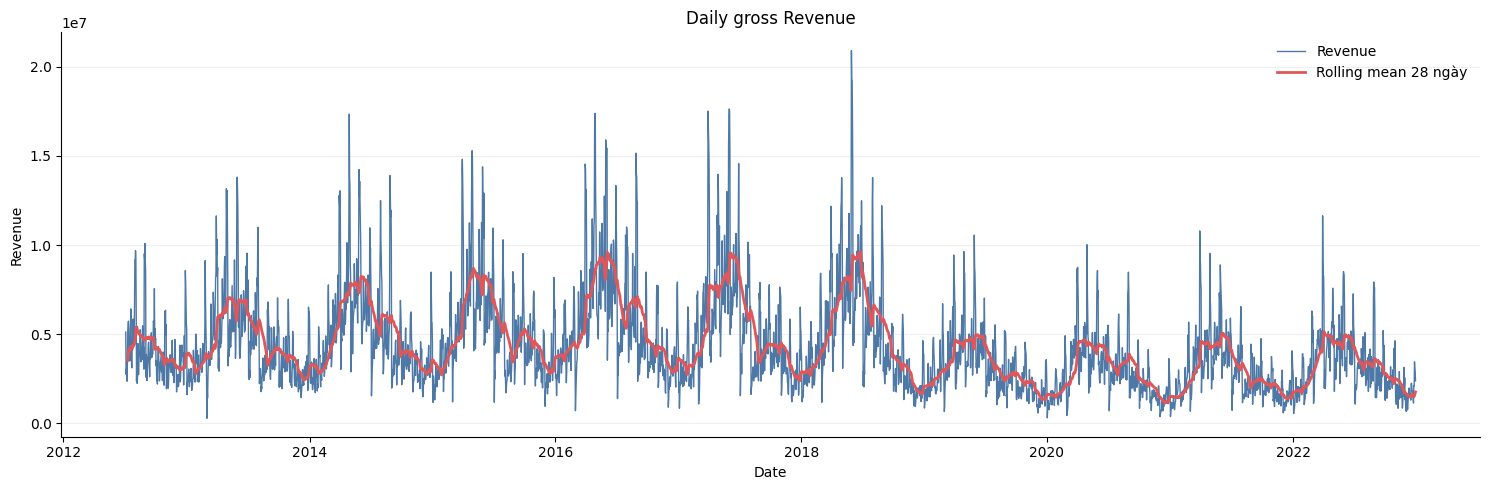

In [42]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(sales["Date"], sales["Revenue"], color="#4E79A7", linewidth=1.0, label="Revenue")
ax.plot(
    sales["Date"],
    sales["Revenue"].rolling(28, min_periods=7).mean(),
    color="#E15759",
    linewidth=2.0,
    label="Rolling mean 28 ngày",
)

ax.set_title("Daily gross Revenue")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

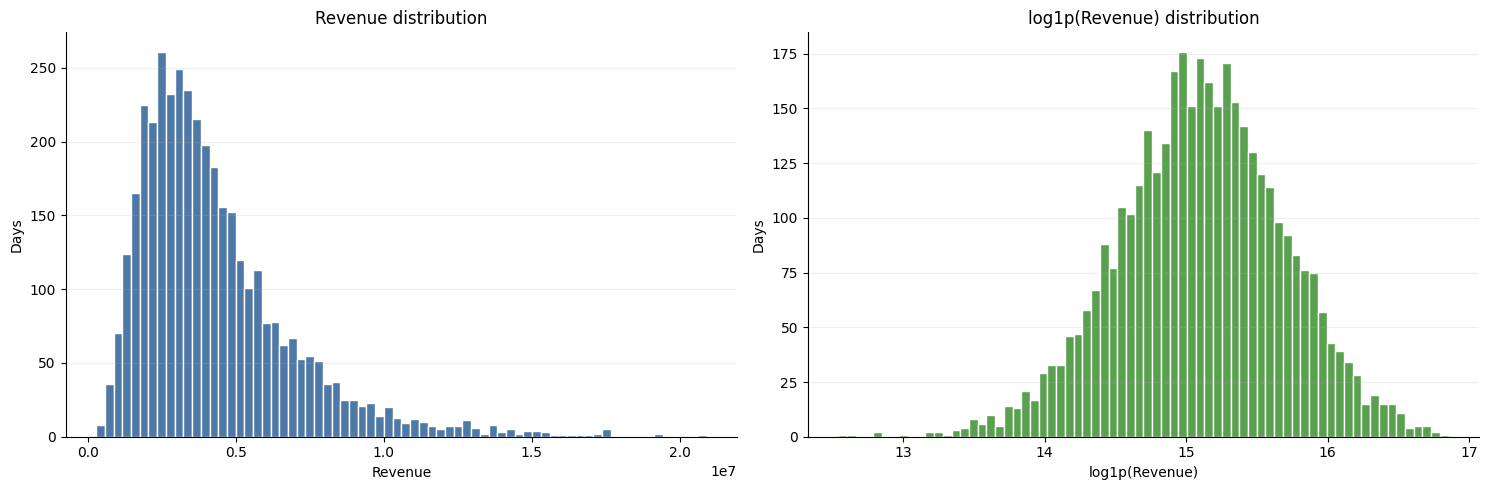

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(sales["Revenue"], bins=70, color="#4E79A7", edgecolor="white")
axes[0].set_title("Revenue distribution")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Days")

axes[1].hist(np.log1p(sales["Revenue"]), bins=70, color="#59A14F", edgecolor="white")
axes[1].set_title("log1p(Revenue) distribution")
axes[1].set_xlabel("log1p(Revenue)")
axes[1].set_ylabel("Days")

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [44]:
q1 = sales["Revenue"].quantile(0.25)
q3 = sales["Revenue"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

revenue_outlier_days = sales.assign(
    revenue_outlier_type=np.select(
        [sales["Revenue"] < lower_bound, sales["Revenue"] > upper_bound],
        ["low_outlier", "high_outlier"],
        default="normal",
    )
).query("revenue_outlier_type != 'normal'")

outlier_summary = pd.DataFrame(
    {
        "lower_bound": [lower_bound],
        "upper_bound": [upper_bound],
        "outlier_days": [len(revenue_outlier_days)],
        "low_outlier_days": [(revenue_outlier_days["revenue_outlier_type"] == "low_outlier").sum()],
        "high_outlier_days": [(revenue_outlier_days["revenue_outlier_type"] == "high_outlier").sum()],
        "outlier_pct": [len(revenue_outlier_days) / len(sales) * 100],
    }
)

display(outlier_summary.round(2))
display(
    revenue_outlier_days
    .sort_values("Revenue", ascending=False)
    .head(20)
    .round({"Revenue": 2, "COGS": 2, "gross_profit": 2, "gross_margin_pct": 4})
)

,lower_bound,upper_bound,outlier_days,low_outlier_days,high_outlier_days,outlier_pct
0,-1848593.75,9670559.77,169,0,169,4.41


,Date,Revenue,COGS,gross_profit,gross_margin_pct,revenue_outlier_type
2156,2018-05-30,20905271.35,16535857.67,4369413.68,0.2090,high_outlier
2157,2018-05-31,19289944.12,15561846.10,3728098.02,0.1933,high_outlier
2158,2018-06-01,19245165.78,15287542.60,3957623.18,0.2056,high_outlier
1793,2017-06-01,17639270.88,14102311.81,3536959.07,0.2005,high_outlier
2159,2018-06-02,17529108.34,13707707.44,3821400.90,0.2180,high_outlier
1794,2017-06-02,17528852.88,14154253.77,3374599.11,0.1925,high_outlier
1730,2017-03-30,17516038.82,16224964.49,1291074.33,0.0737,high_outlier
1394,2016-04-28,17388183.19,13978683.94,3409499.25,0.1961,high_outlier
664,2014-04-29,17347427.27,13752034.86,3595392.41,0.2073,high_outlier
1792,2017-05-31,17314841.86,13846685.08,3468156.78,0.2003,high_outlier


### Phân tích kết quả:
- Dữ liệu có đầy đủ các ngày liên tục.
- Phân phối bị lệch phải rõ ràng.
- Không có ngày có doanh thu thấp bất thường hoặc bằng 0, âm
- Tuy nhiên có nhiều ngày có doanh thu cao hơn so với bình thường, điều này cần phải phân tích thêm
- Giai đoạn từ năm 2019 trở đi, doanh thu giảm so với các giai đoạn trước, lí do cho phần này có thể là do dịch covid khiến cho nhu cầu mua sắm của mọi người giảm

## 2. Trend and seasonality

Mục tiêu của phần này:

- Quan sát xu hướng dài hạn bằng rolling mean 7/28/90 ngày.
- So sánh doanh thu theo năm, quý và tháng.
- Kiểm tra pattern theo day of week.
- So sánh weekend và weekday.
- Kiểm tra hiệu ứng đầu tháng, giữa tháng và cuối tháng như proxy cho month-end/payday effect.

In [45]:
sales_seasonality = sales.copy()
sales_seasonality["year"] = sales_seasonality["Date"].dt.year
sales_seasonality["quarter"] = sales_seasonality["Date"].dt.quarter
sales_seasonality["month"] = sales_seasonality["Date"].dt.month
sales_seasonality["month_name"] = sales_seasonality["Date"].dt.month_name()
sales_seasonality["day_of_week"] = sales_seasonality["Date"].dt.dayofweek
sales_seasonality["day_name"] = sales_seasonality["Date"].dt.day_name()
sales_seasonality["day_of_month"] = sales_seasonality["Date"].dt.day
sales_seasonality["days_to_month_end"] = sales_seasonality["Date"].dt.days_in_month - sales_seasonality["day_of_month"]
sales_seasonality["is_weekend"] = sales_seasonality["day_of_week"].isin([5, 6])
sales_seasonality["month_period"] = np.select(
    [
        sales_seasonality["day_of_month"].le(3),
        sales_seasonality["day_of_month"].between(14, 16),
        sales_seasonality["days_to_month_end"].le(3),
    ],
    ["month_start_1_3", "mid_month_14_16", "month_end_last_4_days"],
    default="regular_days",
)
sales_seasonality["month_name"] = pd.Categorical(
    sales_seasonality["month_name"],
    categories=["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"],
    ordered=True,
)
sales_seasonality["day_name"] = pd.Categorical(
    sales_seasonality["day_name"],
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True,
)

sales_seasonality[["Date", "Revenue", "year", "quarter", "month", "day_name", "is_weekend", "month_period"]].head()

,Date,Revenue,year,quarter,month,day_name,is_weekend,month_period
0,2012-07-04,5123547.94,2012,3,7,Wednesday,False,regular_days
1,2012-07-05,2751773.45,2012,3,7,Thursday,False,regular_days
2,2012-07-06,3054029.42,2012,3,7,Friday,False,regular_days
3,2012-07-07,2667930.94,2012,3,7,Saturday,True,regular_days
4,2012-07-08,2360851.90,2012,3,7,Sunday,True,regular_days


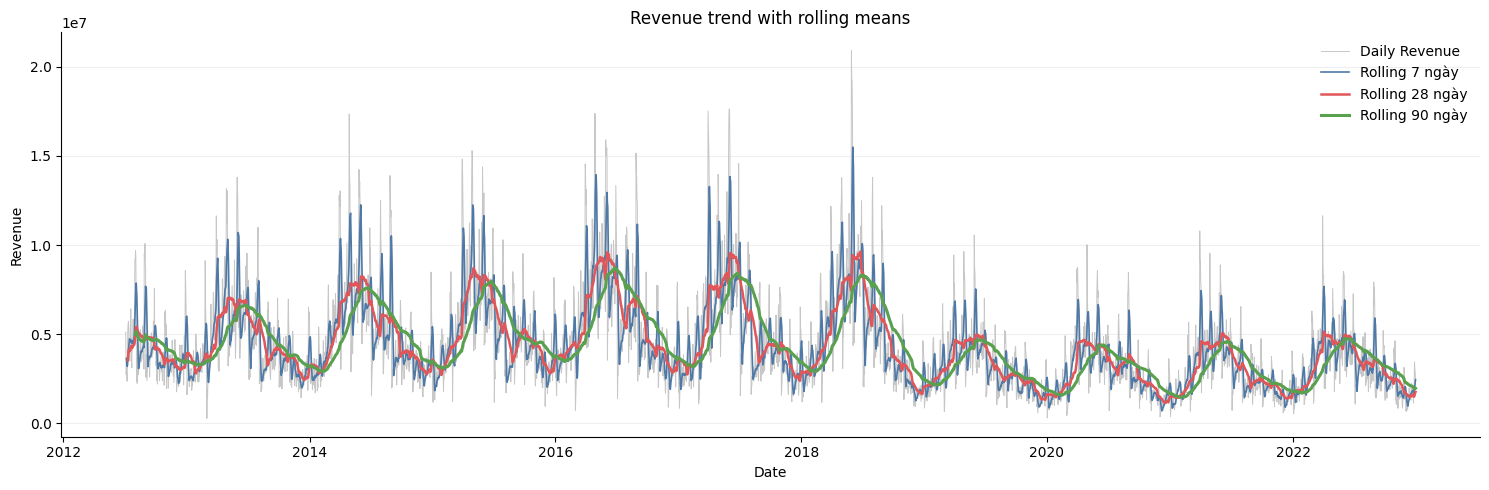

In [46]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(sales_seasonality["Date"], sales_seasonality["Revenue"], color="#C7C7C7", linewidth=0.7, label="Daily Revenue")
ax.plot(sales_seasonality["Date"], sales_seasonality["Revenue"].rolling(7, min_periods=3).mean(), color="#4E79A7", linewidth=1.2, label="Rolling 7 ngày")
ax.plot(sales_seasonality["Date"], sales_seasonality["Revenue"].rolling(28, min_periods=7).mean(), color="#E15759", linewidth=1.8, label="Rolling 28 ngày")
ax.plot(sales_seasonality["Date"], sales_seasonality["Revenue"].rolling(90, min_periods=30).mean(), color="#59A14F", linewidth=2.2, label="Rolling 90 ngày")

ax.set_title("Revenue trend with rolling means")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [47]:
yearly_revenue = (
    sales_seasonality.groupby("year", as_index=False)
    .agg(
        days=("Date", "count"),
        total_revenue=("Revenue", "sum"),
        avg_daily_revenue=("Revenue", "mean"),
        median_daily_revenue=("Revenue", "median"),
    )
)
yearly_revenue["yoy_total_revenue_pct"] = yearly_revenue["total_revenue"].pct_change() * 100
yearly_revenue["yoy_avg_daily_revenue_pct"] = yearly_revenue["avg_daily_revenue"].pct_change() * 100

quarterly_revenue = (
    sales_seasonality.assign(year_quarter=lambda df: df["year"].astype(str) + "Q" + df["quarter"].astype(str))
    .groupby(["year", "quarter", "year_quarter"], as_index=False)
    .agg(
        days=("Date", "count"),
        total_revenue=("Revenue", "sum"),
        avg_daily_revenue=("Revenue", "mean"),
    )
)

monthly_revenue = (
    sales_seasonality.groupby(["year", "month"], as_index=False)
    .agg(
        days=("Date", "count"),
        total_revenue=("Revenue", "sum"),
        avg_daily_revenue=("Revenue", "mean"),
        median_daily_revenue=("Revenue", "median"),
    )
)
monthly_revenue["year_month"] = pd.to_datetime(
    monthly_revenue["year"].astype(str) + "-" + monthly_revenue["month"].astype(str) + "-01"
)

display(yearly_revenue.round(2))
display(quarterly_revenue.tail(12).round(2))
display(monthly_revenue.tail(12).round(2))

,year,days,total_revenue,avg_daily_revenue,median_daily_revenue,yoy_total_revenue_pct,yoy_avg_daily_revenue_pct
0,2012,181,7.414977e+08,4096672.64,3666204.89,NaN,NaN
1,2013,365,1.657169e+09,4540190.18,3927167.34,123.49,10.83
2,2014,365,1.871846e+09,5128344.88,4538183.38,12.95,12.95
3,2015,365,1.889934e+09,5177900.90,4612174.41,0.97,0.97
4,2016,366,2.104641e+09,5750384.36,4934152.38,11.36,11.06
5,2017,365,1.911164e+09,5236066.64,4375381.18,-9.19,-8.94
6,2018,365,1.850122e+09,5068828.65,4317415.31,-3.19,-3.19
7,2019,365,1.136801e+09,3114524.50,2811323.63,-38.56,-38.56
8,2020,366,1.054512e+09,2881180.76,2596347.15,-7.24,-7.49
9,2021,365,1.043040e+09,2857643.34,2480973.68,-1.09,-0.82


,year,quarter,year_quarter,days,total_revenue,avg_daily_revenue
30,2020,1,2020Q1,91,2.219813e+08,2439355.16
31,2020,2,2020Q2,91,3.833895e+08,4213070.98
32,2020,3,2020Q3,92,2.915925e+08,3169483.39
33,2020,4,2020Q4,92,1.575489e+08,1712488.13
34,2021,1,2021Q1,90,2.258247e+08,2509163.77
35,2021,2,2021Q2,91,4.063572e+08,4465463.28
36,2021,3,2021Q3,92,2.441234e+08,2653514.99
37,2021,4,2021Q4,92,1.667345e+08,1812331.98
38,2022,1,2022Q1,90,2.763045e+08,3070050.35
39,2022,2,2022Q2,91,4.161458e+08,4573031.02


,year,month,days,total_revenue,avg_daily_revenue,median_daily_revenue,year_month
114,2022,1,31,5.966349e+07,1924628.59,1758593.80,2022-01-01
115,2022,2,28,7.910310e+07,2825110.55,2490479.86,2022-02-01
116,2022,3,31,1.375379e+08,4436708.04,4325007.40,2022-03-01
117,2022,4,30,1.413055e+08,4710183.63,4689930.65,2022-04-01
118,2022,5,31,1.390279e+08,4484770.55,4323621.35,2022-05-01
119,2022,6,30,1.358124e+08,4527080.89,4246500.07,2022-06-01
120,2022,7,31,9.814178e+07,3165863.80,3238870.01,2022-07-01
121,2022,8,31,1.135429e+08,3662675.60,3292983.26,2022-08-01
122,2022,9,30,8.576429e+07,2858809.55,2596007.00,2022-09-01
123,2022,10,31,7.519445e+07,2425627.49,2345490.55,2022-10-01


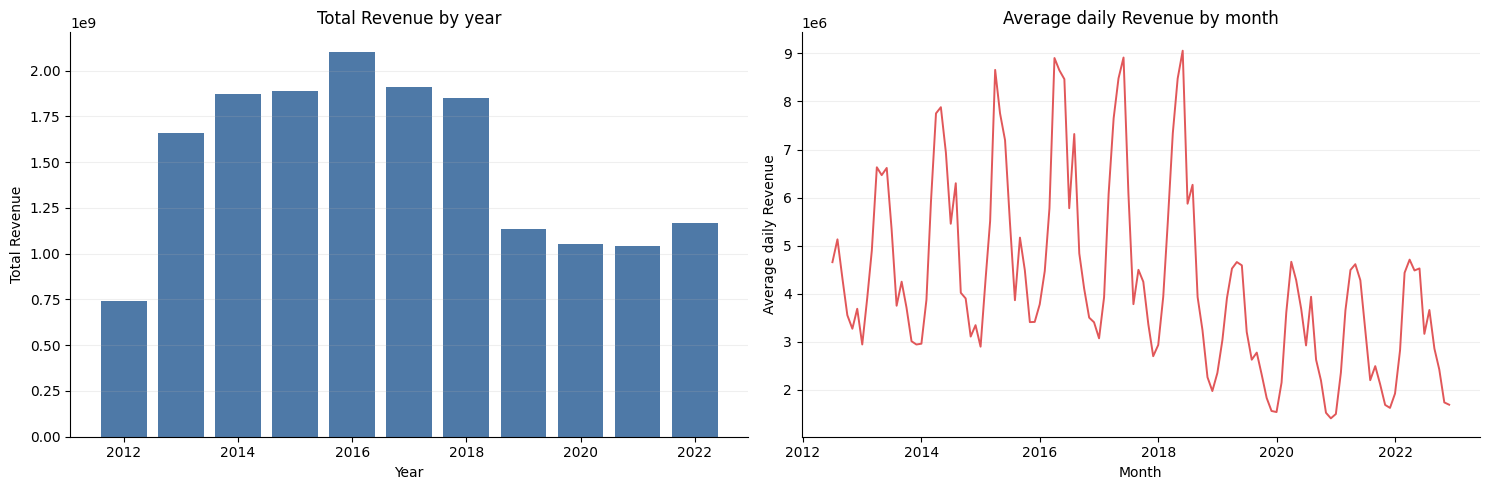

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(yearly_revenue["year"], yearly_revenue["total_revenue"], color="#4E79A7")
axes[0].set_title("Total Revenue by year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total Revenue")

axes[1].plot(monthly_revenue["year_month"], monthly_revenue["avg_daily_revenue"], color="#E15759", linewidth=1.4)
axes[1].set_title("Average daily Revenue by month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average daily Revenue")

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

,month,month_name,days,avg_daily_revenue,median_daily_revenue,p90_daily_revenue
0,1,January,310,2591154.60,2416732.69,4236016.04
1,2,February,282,3480800.78,3242762.87,5467749.71
2,3,March,310,4928185.47,4606234.99,7522416.13
3,4,April,300,6532951.88,5795217.08,11080316.90
4,5,May,310,6575416.35,6067768.61,10751305.33
5,6,June,300,6427108.65,5826463.10,10135327.51
6,7,July,338,4659789.37,4379419.24,7749859.30
7,8,August,341,4441193.49,3646382.12,7969399.16
8,9,September,330,3797825.60,3604251.20,5736830.70
9,10,October,341,3302725.22,3172297.01,5244501.34


,quarter,days,avg_daily_revenue,median_daily_revenue,p90_daily_revenue
0,1,902,3672484.75,3274872.86,6084845.02
1,2,910,6512524.43,5903544.27,10578018.68
2,3,1009,4304002.22,3855254.64,7281632.26
3,4,1012,2814980.11,2587818.66,4508727.37


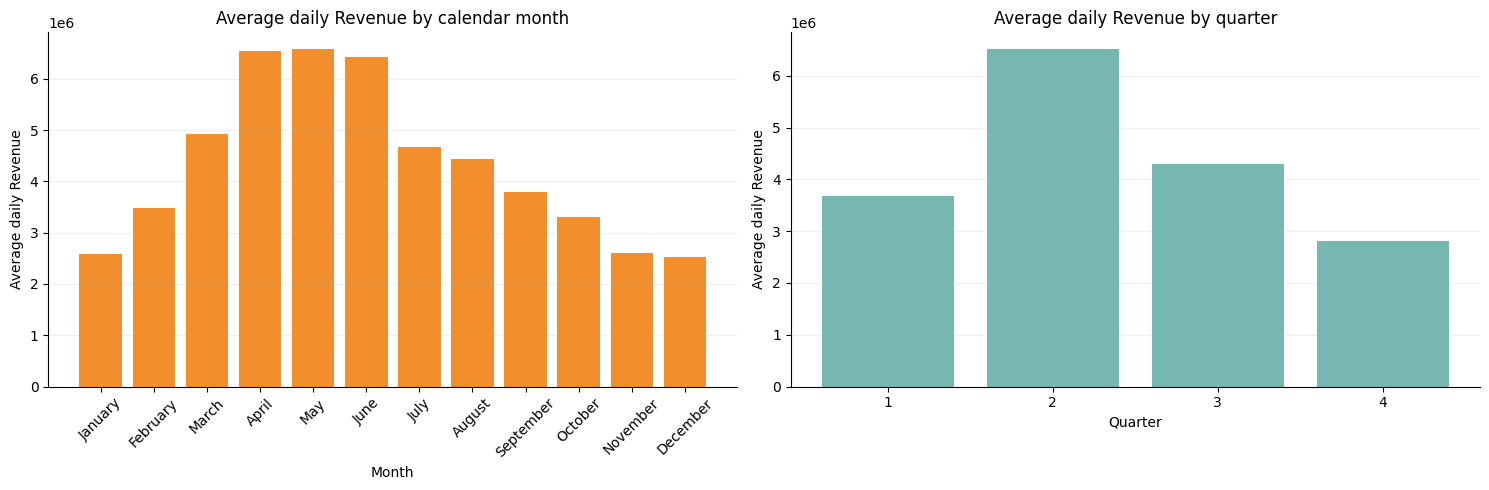

In [49]:
month_seasonality = (
    sales_seasonality.groupby(["month", "month_name"], observed=True, as_index=False)
    .agg(
        days=("Date", "count"),
        avg_daily_revenue=("Revenue", "mean"),
        median_daily_revenue=("Revenue", "median"),
        p90_daily_revenue=("Revenue", lambda s: s.quantile(0.90)),
    )
    .sort_values("month")
)

quarter_seasonality = (
    sales_seasonality.groupby("quarter", as_index=False)
    .agg(
        days=("Date", "count"),
        avg_daily_revenue=("Revenue", "mean"),
        median_daily_revenue=("Revenue", "median"),
        p90_daily_revenue=("Revenue", lambda s: s.quantile(0.90)),
    )
)

display(month_seasonality.round(2))
display(quarter_seasonality.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(month_seasonality["month_name"], month_seasonality["avg_daily_revenue"], color="#F28E2B")
axes[0].set_title("Average daily Revenue by calendar month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Average daily Revenue")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(quarter_seasonality["quarter"].astype(str), quarter_seasonality["avg_daily_revenue"], color="#76B7B2")
axes[1].set_title("Average daily Revenue by quarter")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Average daily Revenue")

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

,day_of_week,day_name,days,avg_daily_revenue,median_daily_revenue,p90_daily_revenue
0,0,Monday,547,4311034.60,3848593.44,7436213.82
1,1,Tuesday,547,4465102.64,3925730.26,8031506.68
2,2,Wednesday,548,4680064.84,3929024.18,8631216.82
3,3,Thursday,548,4523044.05,3629496.98,8415392.87
4,4,Friday,548,4046389.73,3359439.98,7174657.97
5,5,Saturday,548,3906580.84,3384605.36,6878574.60
6,6,Sunday,547,4073853.68,3603536.48,6880618.88


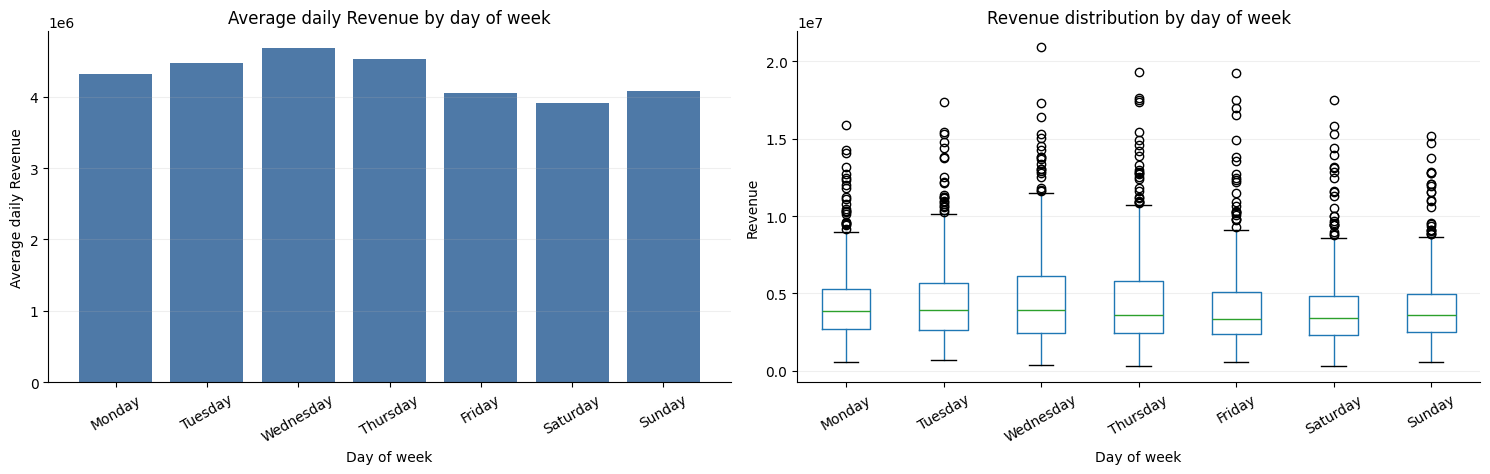

In [50]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_seasonality = (
    sales_seasonality.groupby(["day_of_week", "day_name"], observed=True, as_index=False)
    .agg(
        days=("Date", "count"),
        avg_daily_revenue=("Revenue", "mean"),
        median_daily_revenue=("Revenue", "median"),
        p90_daily_revenue=("Revenue", lambda s: s.quantile(0.90)),
    )
    .sort_values("day_of_week")
)

display(dow_seasonality.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(dow_seasonality["day_name"], dow_seasonality["avg_daily_revenue"], color="#4E79A7")
axes[0].set_title("Average daily Revenue by day of week")
axes[0].set_xlabel("Day of week")
axes[0].set_ylabel("Average daily Revenue")
axes[0].tick_params(axis="x", rotation=30)

sales_seasonality.boxplot(column="Revenue", by="day_name", ax=axes[1], grid=False)
axes[1].set_title("Revenue distribution by day of week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Revenue")
axes[1].tick_params(axis="x", rotation=30)
plt.suptitle("")

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

,day_type,days,avg_daily_revenue,median_daily_revenue,p90_daily_revenue
0,weekday,2738,4405139.63,3734562.94,7935592.17
1,weekend,1095,3990140.88,3501407.51,6881854.24


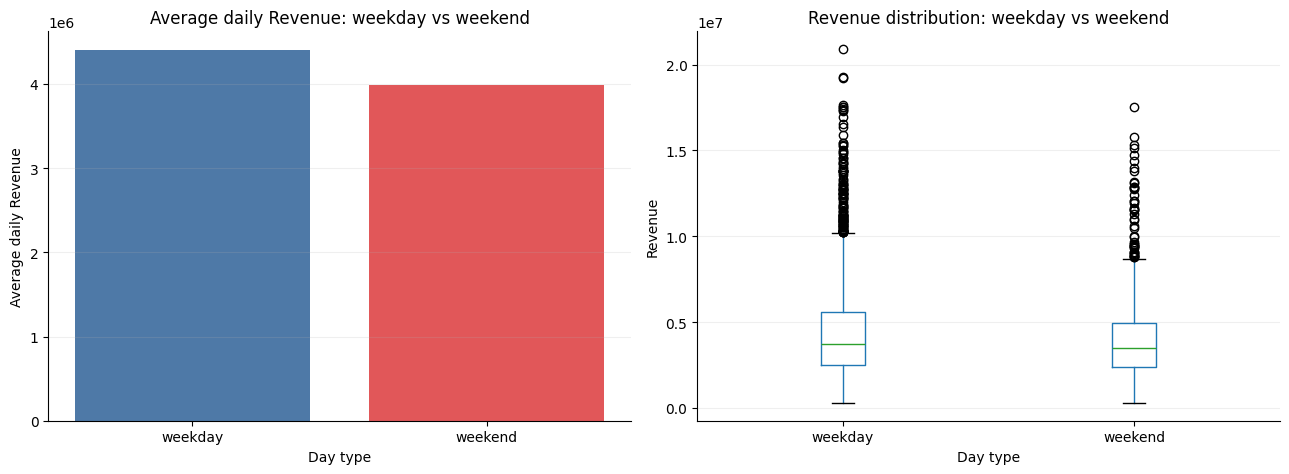

In [51]:
weekend_summary = (
    sales_seasonality.assign(day_type=lambda df: np.where(df["is_weekend"], "weekend", "weekday"))
    .groupby("day_type", as_index=False)
    .agg(
        days=("Date", "count"),
        avg_daily_revenue=("Revenue", "mean"),
        median_daily_revenue=("Revenue", "median"),
        p90_daily_revenue=("Revenue", lambda s: s.quantile(0.90)),
    )
)

display(weekend_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(weekend_summary["day_type"], weekend_summary["avg_daily_revenue"], color=["#4E79A7", "#E15759"])
axes[0].set_title("Average daily Revenue: weekday vs weekend")
axes[0].set_xlabel("Day type")
axes[0].set_ylabel("Average daily Revenue")

sales_seasonality.assign(day_type=lambda df: np.where(df["is_weekend"], "weekend", "weekday")).boxplot(
    column="Revenue",
    by="day_type",
    ax=axes[1],
    grid=False,
)
axes[1].set_title("Revenue distribution: weekday vs weekend")
axes[1].set_xlabel("Day type")
axes[1].set_ylabel("Revenue")
plt.suptitle("")

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

,month_period,days,avg_daily_revenue,median_daily_revenue,p90_daily_revenue
2,month_start_1_3,375,5120412.28,4073777.92,10410412.42
0,mid_month_14_16,378,3968381.56,3700017.93,6516512.12
1,month_end_last_4_days,504,6648153.31,5874194.82,11821213.25
3,regular_days,2576,3749846.46,3327004.01,6407047.39


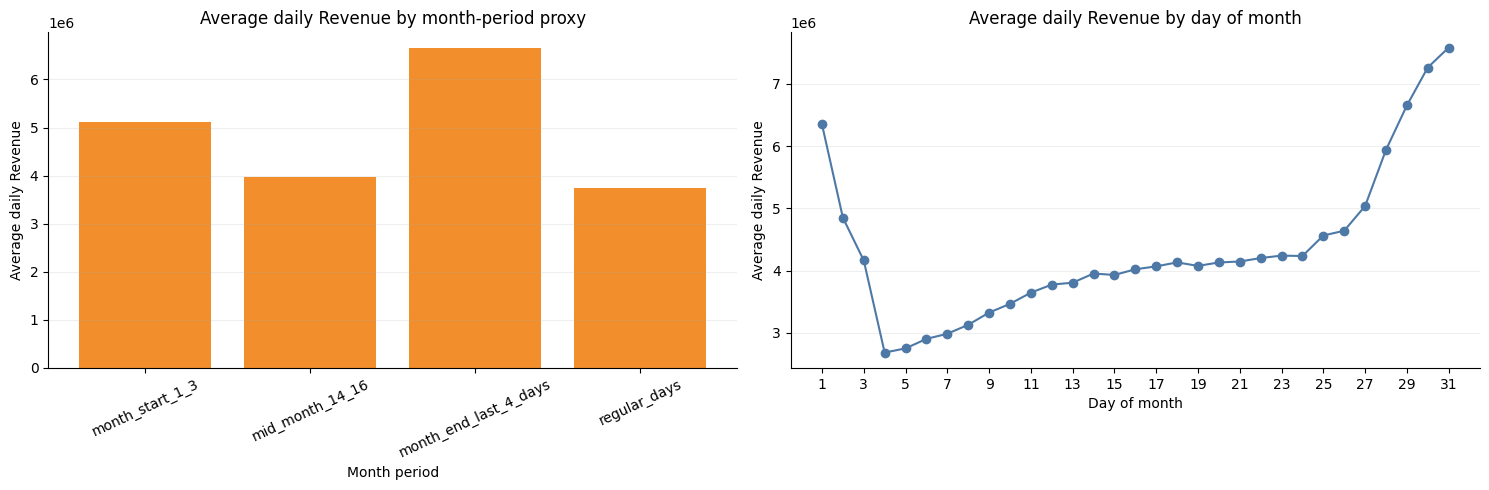

In [52]:
month_period_order = ["month_start_1_3", "mid_month_14_16", "month_end_last_4_days", "regular_days"]

month_period_summary = (
    sales_seasonality.groupby("month_period", as_index=False)
    .agg(
        days=("Date", "count"),
        avg_daily_revenue=("Revenue", "mean"),
        median_daily_revenue=("Revenue", "median"),
        p90_daily_revenue=("Revenue", lambda s: s.quantile(0.90)),
    )
)
month_period_summary["month_period"] = pd.Categorical(
    month_period_summary["month_period"],
    categories=month_period_order,
    ordered=True,
)
month_period_summary = month_period_summary.sort_values("month_period")

day_of_month_summary = (
    sales_seasonality.groupby("day_of_month", as_index=False)
    .agg(
        days=("Date", "count"),
        avg_daily_revenue=("Revenue", "mean"),
        median_daily_revenue=("Revenue", "median"),
    )
)

display(month_period_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(month_period_summary["month_period"].astype(str), month_period_summary["avg_daily_revenue"], color="#F28E2B")
axes[0].set_title("Average daily Revenue by month-period proxy")
axes[0].set_xlabel("Month period")
axes[0].set_ylabel("Average daily Revenue")
axes[0].tick_params(axis="x", rotation=25)

axes[1].plot(day_of_month_summary["day_of_month"], day_of_month_summary["avg_daily_revenue"], marker="o", color="#4E79A7")
axes[1].set_title("Average daily Revenue by day of month")
axes[1].set_xlabel("Day of month")
axes[1].set_ylabel("Average daily Revenue")
axes[1].set_xticks(range(1, 32, 2))

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Phân tích trend and seasonality

Các pattern chính từ phần trend/seasonality:

- Doanh thu có biến động dài hạn rất rõ. Average daily revenue tăng từ khoảng `4.10M` năm 2012 lên đỉnh khoảng `5.75M` năm 2016, sau đó giảm mạnh, đặc biệt từ 2019 trở đi. Năm 2021 là mức thấp nhất trong full-year period, khoảng `2.86M`, rồi 2022 hồi phục lên khoảng `3.20M`.
- Seasonality theo quý rất mạnh. `Q2` là quý cao nhất với average daily revenue khoảng `6.51M`, trong khi `Q4` thấp nhất khoảng `2.81M`. Điều này giải thích vì sao nhiều high outlier tập trung quanh Apr-May-Jun.
- Theo tháng, `May`, `April`, `June` là ba tháng mạnh nhất, lần lượt khoảng `6.58M`, `6.53M`, `6.43M` average daily revenue. Các tháng yếu nhất là `December`, `January`, `November`, đều quanh `2.52M` đến `2.61M`.
- Theo day of week, `Wednesday` cao nhất khoảng `4.68M`, tiếp theo là `Thursday` và `Tuesday`. `Saturday` thấp nhất khoảng `3.91M`.
- Weekend thấp hơn weekday khá rõ: weekday trung bình khoảng `4.41M`, weekend khoảng `3.99M`, tức weekend thấp hơn khoảng `9.42%`.
- Hiệu ứng cuối tháng rất mạnh. `month_end_last_4_days` đạt average daily revenue khoảng `6.65M`, cao hơn regular days khoảng `77.29%`. `month_start_1_3` cũng cao hơn regular days khoảng `36.55%`. Đây là tín hiệu rất quan trọng cho feature engineering.

Hàm ý cho modeling:

- Nên tạo các feature calendar: `year`, `month`, `quarter`, `day_of_week`, `is_weekend`, `day_of_month`, `is_month_start`, `is_month_end`, `days_to_month_end`.
- Nên dùng rolling/lags để mô hình bắt trend thay đổi theo thời gian, vì doanh thu không ổn định quanh một mean cố định.
- Cần đặc biệt kiểm tra các peak cuối tháng và giai đoạn Apr-May-Jun khi xây mô hình dự báo.

### Tết effect

Với bối cảnh người dùng Việt Nam, giai đoạn trước Tết Nguyên đán có thể tạo spike nhu cầu mua sắm. Phần này thêm các biến sự kiện quanh Tết để kiểm tra:

- Doanh thu thay đổi thế nào trong 45 ngày trước Tết và 14 ngày sau Tết.
- Các cửa sổ `pre_tet_1_7d`, `pre_tet_8_14d`, `pre_tet_15_30d`, `pre_tet_31_45d` có doanh thu cao hơn ngày thường không.
- Pattern này có đủ ổn định qua các năm để cân nhắc làm feature cho forecast không.

Lưu ý: danh sách ngày Tết dưới đây được khai báo thủ công cho giai đoạn train và forecast horizon hiện tại.

In [53]:
tet_dates = pd.DataFrame(
    {
        "tet_year": list(range(2013, 2025)),
        "tet_date": pd.to_datetime(
            [
                "2013-02-10",
                "2014-01-31",
                "2015-02-19",
                "2016-02-08",
                "2017-01-28",
                "2018-02-16",
                "2019-02-05",
                "2020-01-25",
                "2021-02-12",
                "2022-02-01",
                "2023-01-22",
                "2024-02-10",
            ]
        ),
    }
)

tet_windows = []
for row in tet_dates.itertuples(index=False):
    window = pd.DataFrame(
        {
            "Date": pd.date_range(row.tet_date - pd.Timedelta(days=45), row.tet_date + pd.Timedelta(days=14)),
            "tet_year": row.tet_year,
            "tet_date": row.tet_date,
        }
    )
    window["days_to_tet"] = (row.tet_date - window["Date"]).dt.days
    tet_windows.append(window)

tet_windows = pd.concat(tet_windows, ignore_index=True)

sales_tet = sales_seasonality.merge(tet_windows, on="Date", how="left")
sales_tet["tet_period"] = np.select(
    [
        sales_tet["days_to_tet"].between(1, 7),
        sales_tet["days_to_tet"].between(8, 14),
        sales_tet["days_to_tet"].between(15, 30),
        sales_tet["days_to_tet"].between(31, 45),
        sales_tet["days_to_tet"].eq(0),
        sales_tet["days_to_tet"].between(-14, -1),
    ],
    ["pre_tet_1_7d", "pre_tet_8_14d", "pre_tet_15_30d", "pre_tet_31_45d", "tet_day", "post_tet_1_14d"],
    default="outside_tet_window",
)

tet_period_order = [
    "pre_tet_31_45d",
    "pre_tet_15_30d",
    "pre_tet_8_14d",
    "pre_tet_1_7d",
    "tet_day",
    "post_tet_1_14d",
    "outside_tet_window",
]
sales_tet["tet_period"] = pd.Categorical(sales_tet["tet_period"], categories=tet_period_order, ordered=True)

display(tet_dates)

,tet_year,tet_date
0,2013,2013-02-10
1,2014,2014-01-31
2,2015,2015-02-19
3,2016,2016-02-08
4,2017,2017-01-28
5,2018,2018-02-16
6,2019,2019-02-05
7,2020,2020-01-25
8,2021,2021-02-12
9,2022,2022-02-01


,tet_period,days,avg_daily_revenue,median_daily_revenue,p90_daily_revenue,lift_vs_outside_pct
0,pre_tet_31_45d,165,2660116.91,2376895.46,4851412.29,-41.67
1,pre_tet_15_30d,169,2593396.06,2383037.48,4108598.03,-43.14
2,pre_tet_8_14d,70,2907292.12,2593634.10,4756901.76,-36.25
3,pre_tet_1_7d,70,2942291.28,2847669.17,4450481.90,-35.49
4,tet_day,10,3280043.36,3567870.49,4009178.67,-28.08
5,post_tet_1_14d,140,3398285.61,3063260.12,5424623.65,-25.49
6,outside_tet_window,3209,4560686.23,3923103.49,8006564.12,0.00


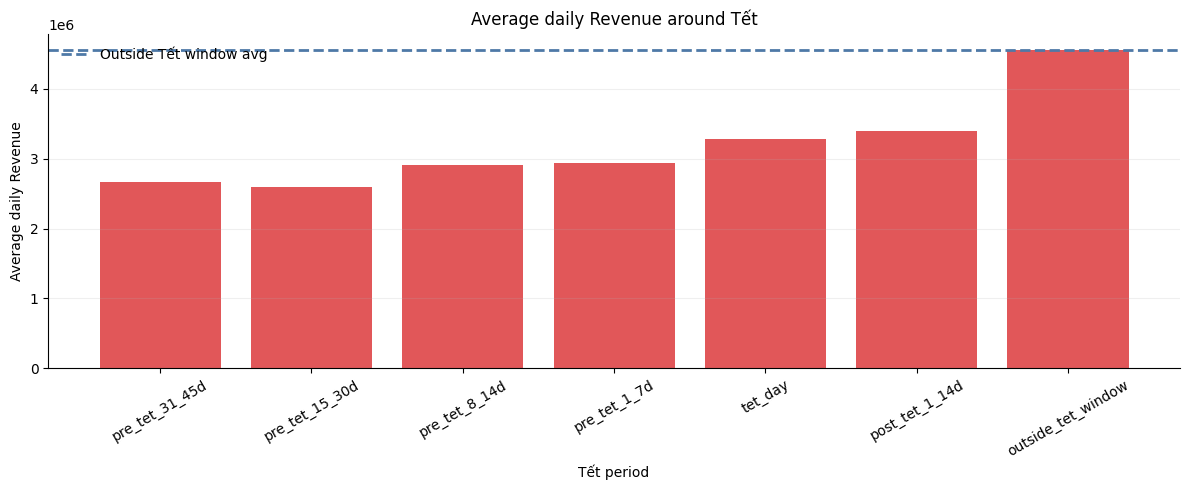

In [54]:
tet_period_summary = (
    sales_tet.groupby("tet_period", observed=True, as_index=False)
    .agg(
        days=("Date", "count"),
        avg_daily_revenue=("Revenue", "mean"),
        median_daily_revenue=("Revenue", "median"),
        p90_daily_revenue=("Revenue", lambda s: s.quantile(0.90)),
    )
)
baseline_revenue = tet_period_summary.loc[
    tet_period_summary["tet_period"].eq("outside_tet_window"),
    "avg_daily_revenue",
].iloc[0]
tet_period_summary["lift_vs_outside_pct"] = (
    tet_period_summary["avg_daily_revenue"] / baseline_revenue - 1
) * 100

display(tet_period_summary.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(tet_period_summary["tet_period"].astype(str), tet_period_summary["avg_daily_revenue"], color="#E15759")
ax.axhline(baseline_revenue, color="#4E79A7", linewidth=2, linestyle="--", label="Outside Tết window avg")
ax.set_title("Average daily Revenue around Tết")
ax.set_xlabel("Tết period")
ax.set_ylabel("Average daily Revenue")
ax.tick_params(axis="x", rotation=30)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

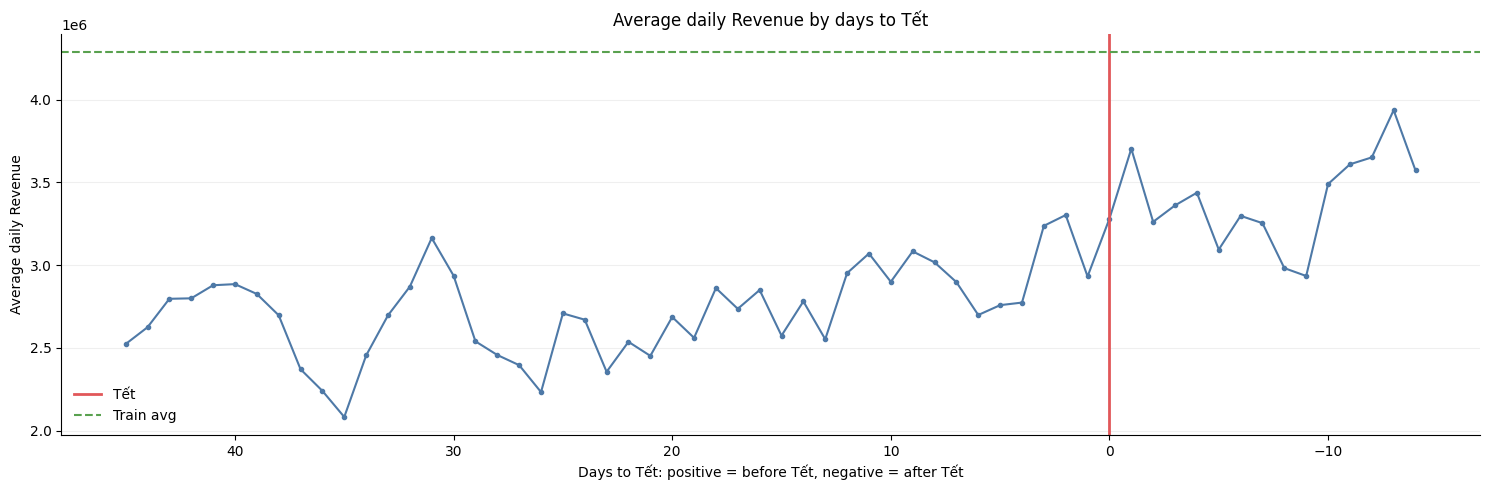

,days_to_tet,days,avg_daily_revenue,median_daily_revenue
59,45.0,11,2522704.72,2792734.55
58,44.0,11,2624184.53,1621284.62
57,43.0,11,2796121.71,2110373.43
56,42.0,11,2798966.48,1553431.51
55,41.0,11,2877933.94,2144901.80
54,40.0,11,2884746.65,2415914.18
53,39.0,11,2825294.57,2536686.97
52,38.0,11,2696669.52,2427966.79
51,37.0,11,2370738.29,2376895.46
50,36.0,11,2239724.89,2500798.47


In [55]:
relative_tet_revenue = (
    sales_tet.dropna(subset=["days_to_tet"])
    .groupby("days_to_tet", as_index=False)
    .agg(
        days=("Date", "count"),
        avg_daily_revenue=("Revenue", "mean"),
        median_daily_revenue=("Revenue", "median"),
    )
    .sort_values("days_to_tet", ascending=False)
)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(relative_tet_revenue["days_to_tet"], relative_tet_revenue["avg_daily_revenue"], color="#4E79A7", linewidth=1.5, marker="o", markersize=3)
ax.axvline(0, color="#E15759", linewidth=2, label="Tết")
ax.axhline(sales["Revenue"].mean(), color="#59A14F", linewidth=1.5, linestyle="--", label="Train avg")
ax.invert_xaxis()
ax.set_title("Average daily Revenue by days to Tết")
ax.set_xlabel("Days to Tết: positive = before Tết, negative = after Tết")
ax.set_ylabel("Average daily Revenue")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

display(relative_tet_revenue.head(12).round(2))

,tet_period,days,avg_daily_revenue,median_daily_revenue,p90_daily_revenue,lift_vs_jan_feb_outside_pct
0,pre_tet_31_45d,66,2165468.77,2253898.26,3034701.54,-45.98
1,pre_tet_15_30d,151,2538786.88,2361866.50,4100379.42,-36.67
2,pre_tet_8_14d,70,2907292.12,2593634.10,4756901.76,-27.48
3,pre_tet_1_7d,70,2942291.28,2847669.17,4450481.90,-26.60
4,tet_day,10,3280043.36,3567870.49,4009178.67,-18.18
5,post_tet_1_14d,133,3364629.00,3050258.51,5159719.38,-16.07
6,outside_tet_window,92,4008685.44,3653282.63,6757315.19,-0.00


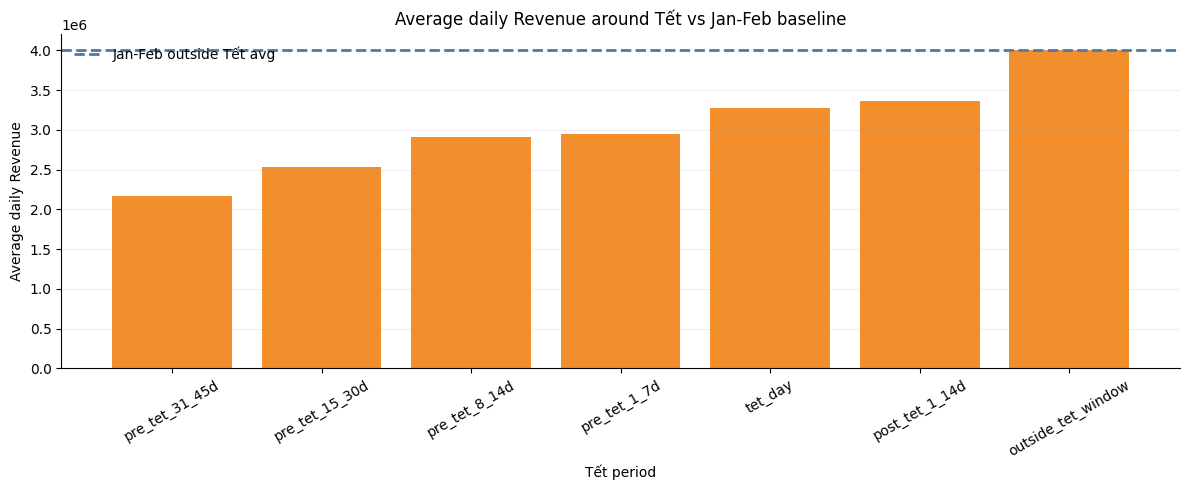

In [56]:
jan_feb_tet = sales_tet[sales_tet["Date"].dt.month.isin([1, 2])].copy()
jan_feb_baseline = jan_feb_tet.loc[
    jan_feb_tet["tet_period"].eq("outside_tet_window"),
    "Revenue",
].mean()

tet_period_jan_feb_summary = (
    jan_feb_tet.groupby("tet_period", observed=True, as_index=False)
    .agg(
        days=("Date", "count"),
        avg_daily_revenue=("Revenue", "mean"),
        median_daily_revenue=("Revenue", "median"),
        p90_daily_revenue=("Revenue", lambda s: s.quantile(0.90)),
    )
)
tet_period_jan_feb_summary["lift_vs_jan_feb_outside_pct"] = (
    tet_period_jan_feb_summary["avg_daily_revenue"] / jan_feb_baseline - 1
) * 100

display(tet_period_jan_feb_summary.round(2))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(
    tet_period_jan_feb_summary["tet_period"].astype(str),
    tet_period_jan_feb_summary["avg_daily_revenue"],
    color="#F28E2B",
)
ax.axhline(jan_feb_baseline, color="#4E79A7", linewidth=2, linestyle="--", label="Jan-Feb outside Tết avg")
ax.set_title("Average daily Revenue around Tết vs Jan-Feb baseline")
ax.set_xlabel("Tết period")
ax.set_ylabel("Average daily Revenue")
ax.tick_params(axis="x", rotation=30)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [57]:
forecast_tet_features = sample_submission[["Date"]].merge(tet_windows, on="Date", how="left")
forecast_tet_features["tet_period"] = np.select(
    [
        forecast_tet_features["days_to_tet"].between(1, 7),
        forecast_tet_features["days_to_tet"].between(8, 14),
        forecast_tet_features["days_to_tet"].between(15, 30),
        forecast_tet_features["days_to_tet"].between(31, 45),
        forecast_tet_features["days_to_tet"].eq(0),
        forecast_tet_features["days_to_tet"].between(-14, -1),
    ],
    ["pre_tet_1_7d", "pre_tet_8_14d", "pre_tet_15_30d", "pre_tet_31_45d", "tet_day", "post_tet_1_14d"],
    default="outside_tet_window",
)

display(
    forecast_tet_features.query("tet_period != 'outside_tet_window'")
    .sort_values("Date")
    .head(80)
)

,Date,tet_year,tet_date,days_to_tet,tet_period
0,2023-01-01,2023.0,2023-01-22,21.0,pre_tet_15_30d
1,2023-01-02,2023.0,2023-01-22,20.0,pre_tet_15_30d
2,2023-01-03,2023.0,2023-01-22,19.0,pre_tet_15_30d
3,2023-01-04,2023.0,2023-01-22,18.0,pre_tet_15_30d
4,2023-01-05,2023.0,2023-01-22,17.0,pre_tet_15_30d
...,...,...,...,...,...
399,2024-02-04,2024.0,2024-02-10,6.0,pre_tet_1_7d
400,2024-02-05,2024.0,2024-02-10,5.0,pre_tet_1_7d
401,2024-02-06,2024.0,2024-02-10,4.0,pre_tet_1_7d
402,2024-02-07,2024.0,2024-02-10,3.0,pre_tet_1_7d


### Phân tích Tết effect

Giả thuyết ban đầu là nhu cầu mua sắm của người Việt có thể tăng mạnh trước Tết. Tuy nhiên, trong dataset này, tín hiệu quan sát được lại ngược lại:

- So với toàn bộ các ngày ngoài cửa sổ Tết, average daily revenue trong các giai đoạn quanh Tết đều thấp hơn. `pre_tet_1_7d` thấp hơn khoảng `35.49%`, `pre_tet_8_14d` thấp hơn khoảng `36.25%`, và `pre_tet_15_30d` thấp hơn khoảng `43.14%`.
- Khi so sánh công bằng hơn với baseline riêng tháng 1-2, kết quả vẫn thấp hơn: `pre_tet_1_7d` thấp hơn khoảng `26.60%`, `pre_tet_8_14d` thấp hơn khoảng `27.48%`, `pre_tet_15_30d` thấp hơn khoảng `36.67%`.
- `post_tet_1_14d` cũng thấp hơn baseline Jan-Feb khoảng `16.07%`, cho thấy giai đoạn ngay sau Tết không phải là peak revenue trong dữ liệu này.
- Doanh thu cao nhất của dataset không nằm quanh Tết mà tập trung rõ hơn vào Apr-May-Jun và các ngày cuối tháng.

Diễn giải:

- Với dữ liệu này, Tết không thể hiện như một peak mua sắm; nó giống một giai đoạn low-season hơn.
- Có thể dataset không đại diện cho ngành hàng tiêu dùng Tết, hoặc hoạt động bán hàng/campaign chính nằm ở giai đoạn khác trong năm.
- Dù vậy, forecast horizon có chứa Tết 2023 và Tết 2024, nên vẫn nên giữ `days_to_tet` và `tet_period` như feature candidate.

Hàm ý cho modeling:

- Có thể tạo feature `days_to_tet`, `is_pre_tet`, `is_tet_day`, `is_post_tet`, `tet_period`.
- Không nên mặc định áp đặt uplift trước Tết; mô hình nên học từ dữ liệu rằng giai đoạn này có xu hướng thấp hơn baseline.
- Cần ưu tiên thêm các feature mạnh hơn đã thấy ở phần seasonality: `month`, `quarter`, `is_month_end`, `days_to_month_end`, `day_of_week`, `is_weekend`.

## 3. Profit and margin

Mục tiêu của phần này:

- Tạo `gross_profit = Revenue - COGS`.
- Tạo `gross_margin_pct = gross_profit / Revenue`.
- Vẽ `Revenue`, `COGS`, `gross_profit` theo thời gian.
- Kiểm tra các ngày `COGS > Revenue`, tức gross margin âm.
- So sánh margin theo tháng và weekday.

In [58]:
sales_profit = sales.copy()
sales_profit["gross_profit"] = sales_profit["Revenue"] - sales_profit["COGS"]
sales_profit["gross_margin_pct"] = sales_profit["gross_profit"] / sales_profit["Revenue"]
sales_profit["year"] = sales_profit["Date"].dt.year
sales_profit["month"] = sales_profit["Date"].dt.month
sales_profit["month_name"] = pd.Categorical(
    sales_profit["Date"].dt.month_name(),
    categories=["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"],
    ordered=True,
)
sales_profit["day_of_week"] = sales_profit["Date"].dt.dayofweek
sales_profit["day_name"] = pd.Categorical(
    sales_profit["Date"].dt.day_name(),
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True,
)

profit_stats = sales_profit[["Revenue", "COGS", "gross_profit", "gross_margin_pct"]].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

display(profit_stats.round(4))

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
Revenue,3833.0,4.286584e+06,2.624840e+06,2.798139e+05,8.450788e+05,1.352929e+06,1.718265e+06,2.471089e+06,3.647304e+06,5.350877e+06,7.685789e+06,9.398760e+06,1.380199e+07,2.090527e+07
COGS,3833.0,3.695134e+06,2.219789e+06,2.365763e+05,7.381388e+05,1.176975e+06,1.514959e+06,2.150580e+06,3.161113e+06,4.637294e+06,6.505817e+06,8.090776e+06,1.157411e+07,1.653586e+07
gross_profit,3833.0,5.914495e+05,6.661960e+05,-2.567312e+06,-1.297737e+06,-8.767850e+04,6.039960e+02,2.292740e+05,5.445544e+05,8.760810e+05,1.353065e+06,1.706283e+06,2.698726e+06,4.369414e+06
gross_margin_pct,3833.0,1.254000e-01,1.274000e-01,-5.746000e-01,-4.116000e-01,-4.450000e-02,2.000000e-04,8.260000e-02,1.783000e-01,2.029000e-01,2.164000e-01,2.254000e-01,2.442000e-01,2.869000e-01


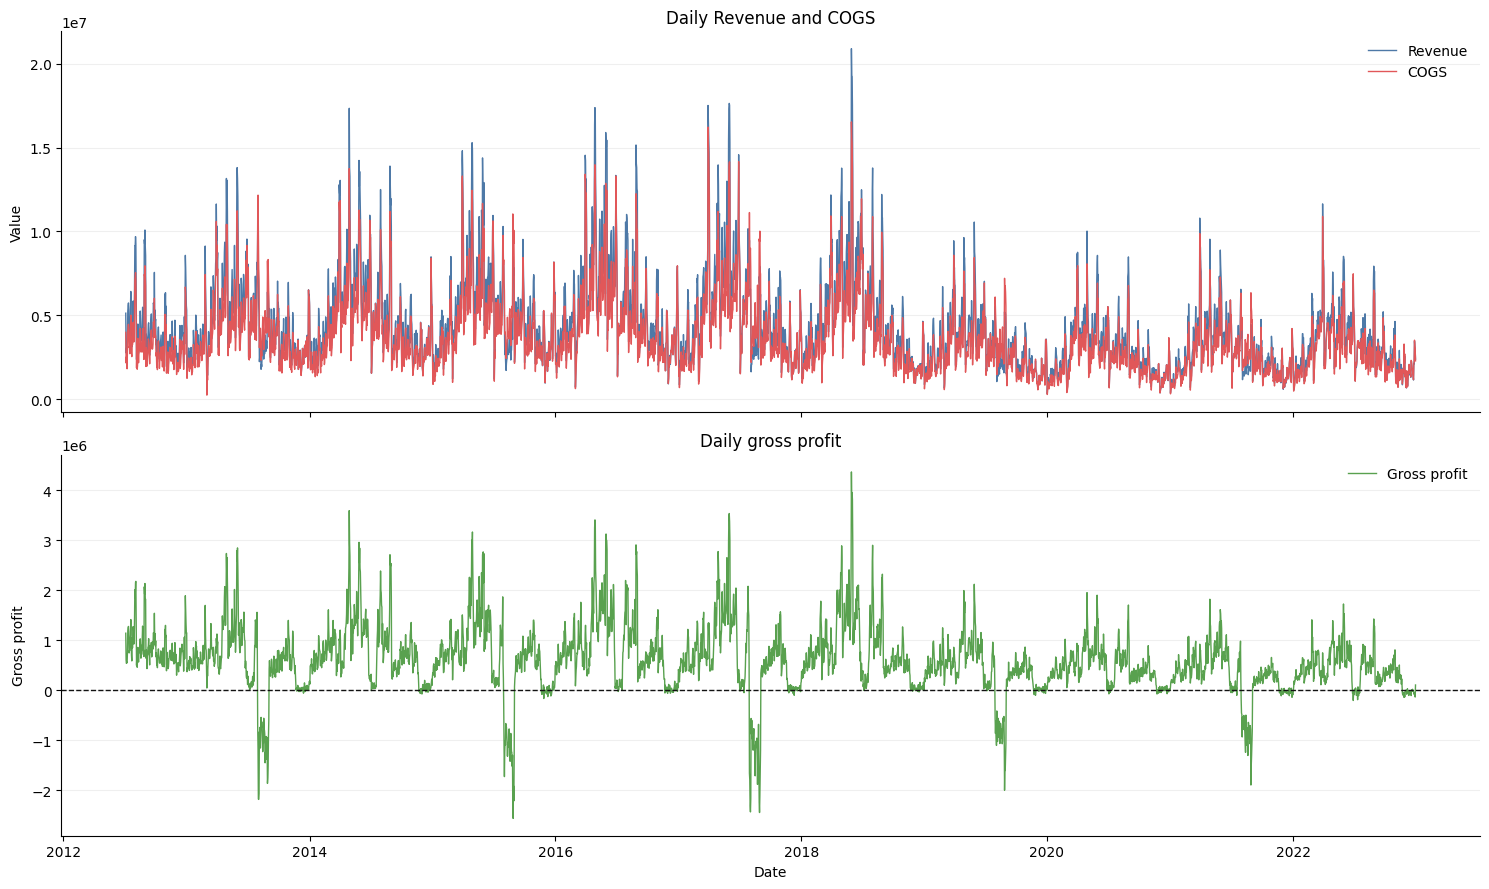

In [59]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

axes[0].plot(sales_profit["Date"], sales_profit["Revenue"], label="Revenue", color="#4E79A7", linewidth=1.0)
axes[0].plot(sales_profit["Date"], sales_profit["COGS"], label="COGS", color="#E15759", linewidth=1.0)
axes[0].set_title("Daily Revenue and COGS")
axes[0].set_ylabel("Value")
axes[0].legend(frameon=False)

axes[1].plot(sales_profit["Date"], sales_profit["gross_profit"], label="Gross profit", color="#59A14F", linewidth=1.0)
axes[1].axhline(0, color="#111111", linewidth=1, linestyle="--")
axes[1].set_title("Daily gross profit")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Gross profit")
axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [60]:
negative_margin_days = sales_profit.query("COGS > Revenue").copy()
negative_margin_summary = pd.DataFrame(
    {
        "negative_margin_days": [len(negative_margin_days)],
        "negative_margin_pct": [len(negative_margin_days) / len(sales_profit) * 100],
        "min_gross_profit": [sales_profit["gross_profit"].min()],
        "min_gross_margin_pct": [sales_profit["gross_margin_pct"].min()],
        "total_negative_gross_profit": [negative_margin_days["gross_profit"].sum()],
    }
)

display(negative_margin_summary.round(4))
display(
    negative_margin_days
    .sort_values("gross_margin_pct")
    .head(20)
    .round({"Revenue": 2, "COGS": 2, "gross_profit": 2, "gross_margin_pct": 4})
)

,negative_margin_days,negative_margin_pct,min_gross_profit,min_gross_margin_pct,total_negative_gross_profit
0,382,9.9661,-2567311.72,-0.5746,-1.922194e+08


,Date,Revenue,COGS,gross_profit,gross_margin_pct,year,month,month_name,day_of_week,day_name
3323,2021-08-09,1376421.76,2167285.81,-790864.05,-0.5746,2021,8,August,0,Monday
3340,2021-08-26,1886569.08,2959216.09,-1072647.01,-0.5686,2021,8,August,3,Thursday
3327,2021-08-13,2199306.57,3444159.74,-1244853.17,-0.5660,2021,8,August,4,Friday
3338,2021-08-24,1836322.27,2808012.60,-971690.33,-0.5292,2021,8,August,1,Tuesday
3334,2021-08-20,2553183.49,3860236.79,-1307053.30,-0.5119,2021,8,August,4,Friday
3325,2021-08-11,1740229.21,2604985.61,-864756.40,-0.4969,2021,8,August,2,Wednesday
3330,2021-08-16,2220064.67,3319453.91,-1099389.24,-0.4952,2021,8,August,0,Monday
3320,2021-08-06,1591502.80,2374360.64,-782857.84,-0.4919,2021,8,August,4,Friday
3342,2021-08-28,1664938.51,2453257.65,-788319.14,-0.4735,2021,8,August,5,Saturday
3331,2021-08-17,2263302.37,3320429.89,-1057127.52,-0.4671,2021,8,August,1,Tuesday


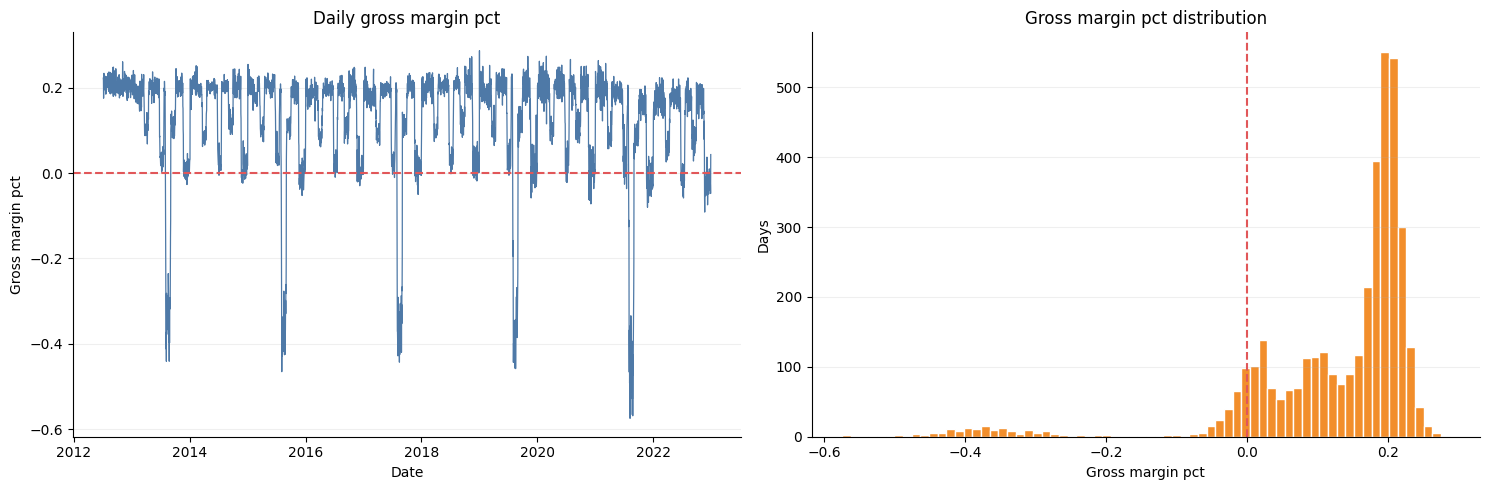

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(sales_profit["Date"], sales_profit["gross_margin_pct"], color="#4E79A7", linewidth=0.9)
axes[0].axhline(0, color="#E15759", linewidth=1.5, linestyle="--")
axes[0].set_title("Daily gross margin pct")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Gross margin pct")

axes[1].hist(sales_profit["gross_margin_pct"], bins=70, color="#F28E2B", edgecolor="white")
axes[1].axvline(0, color="#E15759", linewidth=1.5, linestyle="--")
axes[1].set_title("Gross margin pct distribution")
axes[1].set_xlabel("Gross margin pct")
axes[1].set_ylabel("Days")

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [62]:
monthly_margin = (
    sales_profit.groupby(["month", "month_name"], observed=True, as_index=False)
    .agg(
        days=("Date", "count"),
        avg_revenue=("Revenue", "mean"),
        avg_gross_profit=("gross_profit", "mean"),
        avg_margin_pct=("gross_margin_pct", "mean"),
        median_margin_pct=("gross_margin_pct", "median"),
        negative_margin_days=("gross_margin_pct", lambda s: int((s < 0).sum())),
    )
)
monthly_margin["negative_margin_pct"] = monthly_margin["negative_margin_days"] / monthly_margin["days"] * 100

weekday_margin = (
    sales_profit.groupby(["day_of_week", "day_name"], observed=True, as_index=False)
    .agg(
        days=("Date", "count"),
        avg_revenue=("Revenue", "mean"),
        avg_gross_profit=("gross_profit", "mean"),
        avg_margin_pct=("gross_margin_pct", "mean"),
        median_margin_pct=("gross_margin_pct", "median"),
        negative_margin_days=("gross_margin_pct", lambda s: int((s < 0).sum())),
    )
)
weekday_margin["negative_margin_pct"] = weekday_margin["negative_margin_days"] / weekday_margin["days"] * 100

display(monthly_margin.round(4))
display(weekday_margin.round(4))

,month,month_name,days,avg_revenue,avg_gross_profit,avg_margin_pct,median_margin_pct,negative_margin_days,negative_margin_pct
0,1,January,310,2.591155e+06,4.875343e+05,0.1905,0.1952,2,0.6452
1,2,February,282,3.480801e+06,6.565086e+05,0.1889,0.1892,0,0.0000
2,3,March,310,4.928185e+06,6.977512e+05,0.1547,0.1713,0,0.0000
3,4,April,300,6.532952e+06,1.007082e+06,0.1461,0.1431,0,0.0000
4,5,May,310,6.575416e+06,1.312004e+06,0.1992,0.1999,0,0.0000
5,6,June,300,6.427109e+06,1.036184e+06,0.1641,0.1927,6,2.0000
6,7,July,338,4.659789e+06,4.625248e+05,0.0901,0.0507,33,9.7633
7,8,August,341,4.441193e+06,9.281565e+04,-0.0564,0.1663,155,45.4545
8,9,September,330,3.797826e+06,4.199217e+05,0.1086,0.1103,9,2.7273
9,10,October,341,3.302725e+06,6.480116e+05,0.1958,0.1976,0,0.0000


,day_of_week,day_name,days,avg_revenue,avg_gross_profit,avg_margin_pct,median_margin_pct,negative_margin_days,negative_margin_pct
0,0,Monday,547,4.311035e+06,596905.8618,0.1250,0.1799,52,9.5064
1,1,Tuesday,547,4.465103e+06,625188.9002,0.1257,0.1784,52,9.5064
2,2,Wednesday,548,4.680065e+06,652145.3344,0.1256,0.1779,54,9.8540
3,3,Thursday,548,4.523044e+06,617743.6504,0.1247,0.1769,58,10.5839
4,4,Friday,548,4.046390e+06,551394.6790,0.1255,0.1799,60,10.9489
5,5,Saturday,548,3.906581e+06,534613.4893,0.1245,0.1788,55,10.0365
6,6,Sunday,547,4.073854e+06,562172.9280,0.1268,0.1771,51,9.3236


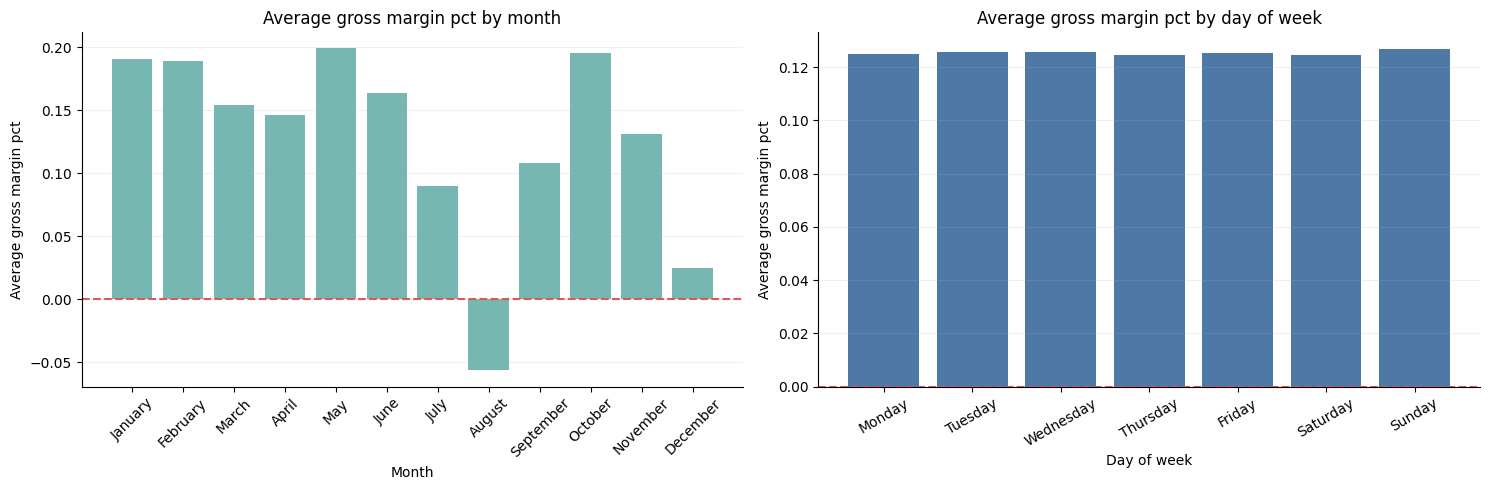

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(monthly_margin["month_name"].astype(str), monthly_margin["avg_margin_pct"], color="#76B7B2")
axes[0].axhline(0, color="#E15759", linewidth=1.5, linestyle="--")
axes[0].set_title("Average gross margin pct by month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Average gross margin pct")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(weekday_margin["day_name"].astype(str), weekday_margin["avg_margin_pct"], color="#4E79A7")
axes[1].axhline(0, color="#E15759", linewidth=1.5, linestyle="--")
axes[1].set_title("Average gross margin pct by day of week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("Average gross margin pct")
axes[1].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Forecast horizon

Mục tiêu của phần này:

- So sánh `sample_submission.Date` với train date range.
- Kiểm tra horizon dài bao nhiêu ngày.
- Xem forecast period rơi vào tháng/quý/weekday nào.

In [64]:
forecast_calendar = sample_submission[["Date"]].copy()
forecast_calendar["year"] = forecast_calendar["Date"].dt.year
forecast_calendar["quarter"] = forecast_calendar["Date"].dt.quarter
forecast_calendar["month"] = forecast_calendar["Date"].dt.month
forecast_calendar["month_name"] = pd.Categorical(
    forecast_calendar["Date"].dt.month_name(),
    categories=["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"],
    ordered=True,
)
forecast_calendar["day_of_week"] = forecast_calendar["Date"].dt.dayofweek
forecast_calendar["day_name"] = pd.Categorical(
    forecast_calendar["Date"].dt.day_name(),
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True,
)
forecast_calendar["is_weekend"] = forecast_calendar["day_of_week"].isin([5, 6])
forecast_calendar["days_to_month_end"] = forecast_calendar["Date"].dt.days_in_month - forecast_calendar["Date"].dt.day
forecast_calendar["is_month_end_window"] = forecast_calendar["days_to_month_end"].le(3)

forecast_horizon_summary = pd.DataFrame(
    {
        "train_start": [sales["Date"].min()],
        "train_end": [sales["Date"].max()],
        "forecast_start": [forecast_calendar["Date"].min()],
        "forecast_end": [forecast_calendar["Date"].max()],
        "forecast_rows": [len(forecast_calendar)],
        "forecast_calendar_days": [(forecast_calendar["Date"].max() - forecast_calendar["Date"].min()).days + 1],
        "gap_after_train_days": [(forecast_calendar["Date"].min() - sales["Date"].max()).days],
        "forecast_month_end_window_days": [int(forecast_calendar["is_month_end_window"].sum())],
    }
)

display(forecast_horizon_summary)
display(forecast_calendar.groupby(["year", "quarter"], as_index=False).size().rename(columns={"size": "days"}))
display(forecast_calendar.groupby(["month", "month_name"], observed=True, as_index=False).size().rename(columns={"size": "days"}))
display(forecast_calendar.groupby(["day_of_week", "day_name"], observed=True, as_index=False).size().rename(columns={"size": "days"}))

,train_start,train_end,forecast_start,forecast_end,forecast_rows,forecast_calendar_days,gap_after_train_days,forecast_month_end_window_days
0,2012-07-04,2022-12-31,2023-01-01,2024-07-01,548,548,1,72


,year,quarter,days
0,2023,1,90
1,2023,2,91
2,2023,3,92
3,2023,4,92
4,2024,1,91
5,2024,2,91
6,2024,3,1


,month,month_name,days
0,1,January,62
1,2,February,57
2,3,March,62
3,4,April,60
4,5,May,62
5,6,June,60
6,7,July,32
7,8,August,31
8,9,September,30
9,10,October,31


,day_of_week,day_name,days
0,0,Monday,79
1,1,Tuesday,78
2,2,Wednesday,78
3,3,Thursday,78
4,4,Friday,78
5,5,Saturday,78
6,6,Sunday,79


### Phân tích forecast horizon

- Forecast horizon chạy từ `2023-01-01` đến `2024-07-01`, gồm `548` ngày liên tục. Gap sau ngày train cuối là `1` ngày, nên đây là bài toán dự báo nối tiếp theo thời gian.
- Horizon bao phủ trọn năm 2023, Q1-Q2 năm 2024 và thêm `1` ngày của Q3/2024. Vì vậy mô hình cần học được cả trend dài hạn, seasonality theo tháng/quý, weekend/weekday và hiệu ứng cuối tháng.
- Forecast period có `157` ngày weekend và `72` ngày thuộc cửa sổ cuối tháng. Đây là các calendar effects đã có tín hiệu trong train.
- Forecast period cũng có các tháng cao điểm trong train như Apr-May-Jun, đồng thời có Tết 2023 và Tết 2024.
- Vì sample submission chỉ có date trong tương lai, các feature chắc chắn biết trước gồm calendar features: `month`, `quarter`, `day_of_week`, `is_weekend`, `is_month_end_window`, `days_to_month_end`, `tet_period`. Các feature từ orders/items/web/inventory cần dùng dạng lag/rolling hoặc được xác nhận là biết trước.

## 5. Orders daily aggregates

Tạo các aggregate theo ngày từ `orders`: order count, unique customers, average revenue per order, status/source/device/payment mix. Các biến same-day này dùng cho EDA; nếu đưa vào modeling forecast tương lai thì cần chuyển sang lag/rolling.

In [65]:
orders_full = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])

orders_daily = (
    orders_full.groupby("order_date", as_index=False)
    .agg(
        order_count=("order_id", "count"),
        unique_customers=("customer_id", "nunique"),
    )
    .rename(columns={"order_date": "Date"})
)

orders_daily = sales[["Date", "Revenue"]].merge(orders_daily, on="Date", how="left").fillna({"order_count": 0, "unique_customers": 0})
orders_daily["avg_revenue_per_order"] = orders_daily["Revenue"] / orders_daily["order_count"].replace(0, np.nan)

status_daily_share = pd.crosstab(orders_full["order_date"], orders_full["order_status"], normalize="index").reset_index().rename(columns={"order_date": "Date"})
source_daily_share = pd.crosstab(orders_full["order_date"], orders_full["order_source"], normalize="index").reset_index().rename(columns={"order_date": "Date"})
device_daily_share = pd.crosstab(orders_full["order_date"], orders_full["device_type"], normalize="index").reset_index().rename(columns={"order_date": "Date"})
payment_daily_share = pd.crosstab(orders_full["order_date"], orders_full["payment_method"], normalize="index").reset_index().rename(columns={"order_date": "Date"})

orders_summary = orders_daily[["order_count", "unique_customers", "avg_revenue_per_order"]].describe().T
orders_revenue_corr = orders_daily[["Revenue", "order_count", "unique_customers", "avg_revenue_per_order"]].corr()["Revenue"].drop("Revenue").to_frame("corr_with_revenue")

display(orders_summary.round(2))
display(orders_revenue_corr.round(4))
display(orders_full["order_status"].value_counts(normalize=True).mul(100).rename("order_status_pct").round(2).to_frame())
display(orders_full["order_source"].value_counts(normalize=True).mul(100).rename("order_source_pct").round(2).to_frame())
display(orders_full["device_type"].value_counts(normalize=True).mul(100).rename("device_type_pct").round(2).to_frame())
display(orders_full["payment_method"].value_counts(normalize=True).mul(100).rename("payment_method_pct").round(2).to_frame())

,count,mean,std,min,25%,50%,75%,max
order_count,3833.0,168.78,111.06,8.00,92.00,139.00,217.00,803.00
unique_customers,3833.0,167.46,109.87,8.00,91.00,138.00,215.00,791.00
avg_revenue_per_order,3833.0,26754.07,5765.81,10983.75,23398.56,26714.65,30420.69,55063.14


,corr_with_revenue
order_count,0.9359
unique_customers,0.9370
avg_revenue_per_order,-0.0730


,order_status_pct
order_status,
delivered,79.87
cancelled,9.19
returned,5.59
shipped,2.13
paid,2.10
created,1.12


,order_source_pct
order_source,
organic_search,28.05
paid_search,21.90
social_media,20.05
email_campaign,11.99
referral,9.98
direct,8.03


,device_type_pct
device_type,
mobile,45.06
desktop,40.01
tablet,14.93


,payment_method_pct
payment_method,
credit_card,55.08
paypal,15.00
cod,14.94
apple_pay,10.01
bank_transfer,4.97


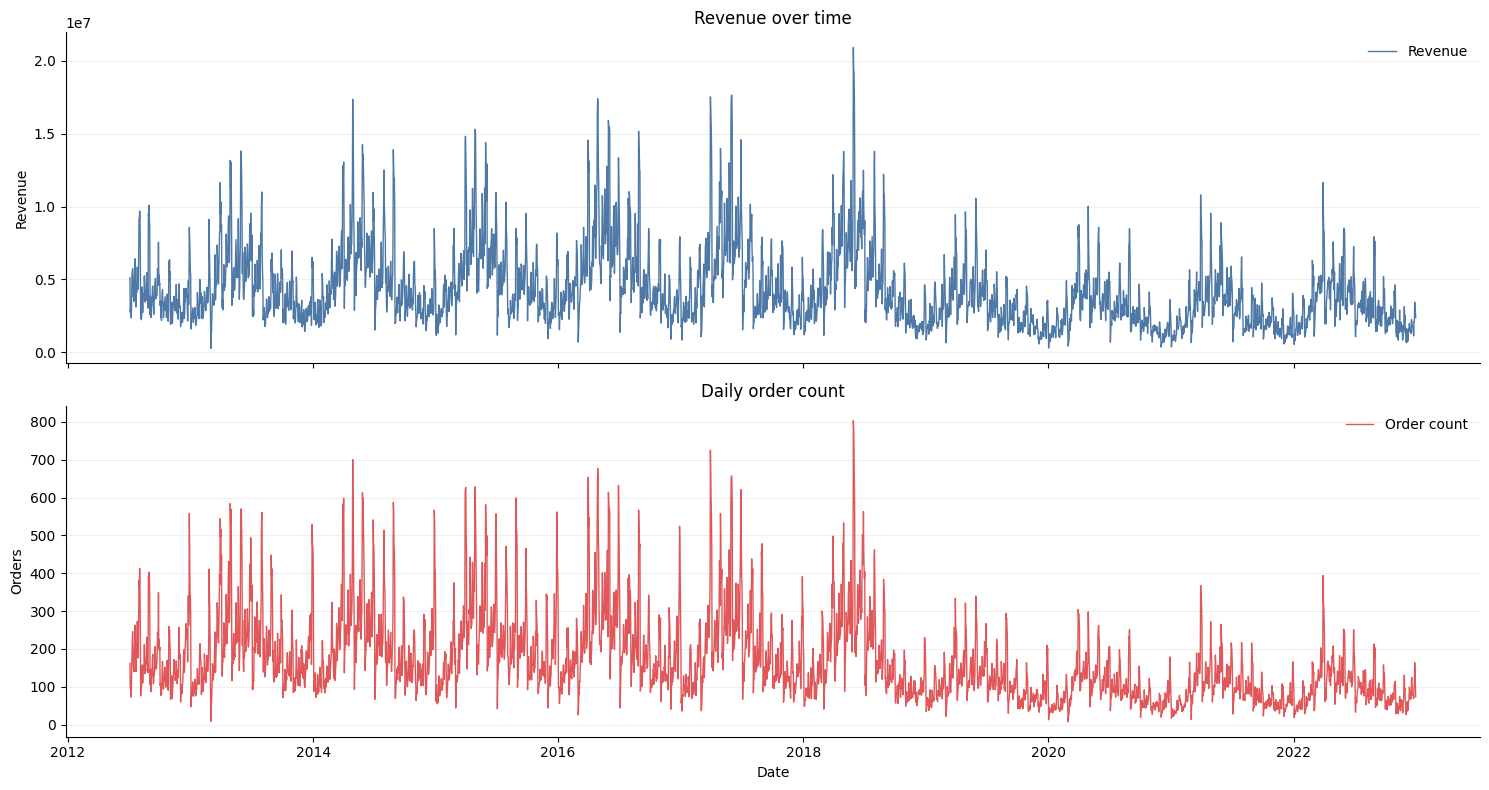

In [66]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(orders_daily["Date"], orders_daily["Revenue"], color="#4E79A7", linewidth=1.0, label="Revenue")
axes[0].set_title("Revenue over time")
axes[0].set_ylabel("Revenue")
axes[0].legend(frameon=False)

axes[1].plot(orders_daily["Date"], orders_daily["order_count"], color="#E15759", linewidth=1.0, label="Order count")
axes[1].set_title("Daily order count")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Orders")
axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Phân tích orders daily aggregates

- `order_count` và `unique_customers` giải thích rất mạnh cho doanh thu theo ngày. Correlation với `Revenue` lần lượt khoảng `0.936` và `0.937`, cho thấy biến động doanh thu chủ yếu đến từ volume đơn hàng/người mua.
- `avg_revenue_per_order` gần như không đồng biến với Revenue trong aggregate daily, correlation khoảng `-0.073`. Vì vậy spike doanh thu có vẻ đến từ số lượng đơn/khách hơn là ticket size trung bình.
- Status/source/device/payment mix hữu ích để hiểu cơ cấu đơn hàng, nhưng cùng ngày không biết trước trong forecast. Khi modeling nên dùng lag/rolling share, ví dụ `order_count_lag_7`, `paid_search_share_rolling_28`, `mobile_share_lag_7`.

## 6. Items/products daily aggregates

Tạo các aggregate theo ngày từ `order_items` và `products`: quantity sold, discount amount, discount rate, unique products, category mix và top product/category contribution.

In [67]:
products = pd.read_csv(DATA_DIR / "products.csv")
order_item_daily_base = (
    order_items_prepared.merge(orders_full[["order_id", "order_date"]], on="order_id", how="left")
    .merge(products[["product_id", "product_name", "category", "segment", "cogs"]], on="product_id", how="left")
)
order_item_daily_base["calculated_cogs"] = order_item_daily_base["quantity"] * order_item_daily_base["cogs"]
order_item_daily_base["has_promo"] = order_item_daily_base[["promo_id", "promo_id_2"]].notna().any(axis=1)

items_daily = (
    order_item_daily_base.groupby("order_date", as_index=False)
    .agg(
        quantity_sold=("quantity", "sum"),
        gross_revenue_items=("gross_revenue", "sum"),
        discount_amount=("discount_amount", "sum"),
        net_revenue_items=("net_revenue", "sum"),
        calculated_cogs=("calculated_cogs", "sum"),
        unique_products_sold=("product_id", "nunique"),
        promo_item_lines=("has_promo", "sum"),
        item_lines=("product_id", "size"),
    )
    .rename(columns={"order_date": "Date"})
)
items_daily["discount_rate"] = items_daily["discount_amount"] / items_daily["gross_revenue_items"].replace(0, np.nan)
items_daily["promo_item_line_pct"] = items_daily["promo_item_lines"] / items_daily["item_lines"] * 100

items_daily = sales[["Date", "Revenue"]].merge(items_daily, on="Date", how="left")
items_corr = items_daily[["Revenue", "quantity_sold", "discount_amount", "discount_rate", "unique_products_sold", "promo_item_line_pct"]].corr()["Revenue"].drop("Revenue").to_frame("corr_with_revenue")

category_contribution = (
    order_item_daily_base.groupby("category", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        quantity=("quantity", "sum"),
        unique_products=("product_id", "nunique"),
    )
    .assign(revenue_share_pct=lambda df: df["gross_revenue"] / df["gross_revenue"].sum() * 100)
    .sort_values("gross_revenue", ascending=False)
)

top_product_contribution = (
    order_item_daily_base.groupby(["product_id", "product_name", "category"], as_index=False)
    .agg(gross_revenue=("gross_revenue", "sum"), quantity=("quantity", "sum"))
    .assign(revenue_share_pct=lambda df: df["gross_revenue"] / df["gross_revenue"].sum() * 100)
    .sort_values("gross_revenue", ascending=False)
    .head(20)
)

display(items_daily[["quantity_sold", "discount_amount", "discount_rate", "unique_products_sold", "promo_item_line_pct"]].describe().T.round(4))
display(items_corr.round(4))
display(category_contribution.round(2))
display(top_product_contribution.round(2))

,count,mean,std,min,25%,50%,75%,max
quantity_sold,3833.0,838.2841,562.5639,29.0,447.0,687.0,1090.00,3879.00
discount_amount,3833.0,195566.7415,331261.7403,0.0,0.0,0.0,320367.19,2623653.76
discount_rate,3833.0,0.0517,0.0738,0.0,0.0,0.0,0.10,0.20
unique_products_sold,3833.0,107.8847,45.6154,6.0,74.0,102.0,137.00,275.00
promo_item_line_pct,3833.0,36.8361,44.9159,0.0,0.0,0.0,100.00,100.00


,corr_with_revenue
quantity_sold,0.9178
discount_amount,0.2320
discount_rate,-0.1342
unique_products_sold,0.9113
promo_item_line_pct,-0.1114


,category,gross_revenue,quantity,unique_products,revenue_share_pct
3,Streetwear,1.313135e+10,1768826,877,79.92
2,Outdoor,2.494883e+09,1170000,496,15.18
0,Casual,4.606484e+08,107469,114,2.80
1,GenZ,3.435991e+08,166848,111,2.09


,product_id,product_name,category,gross_revenue,quantity,revenue_share_pct
308,487,SaigonFlex UM-92,Streetwear,3.982136e+08,33277,2.42
566,826,HanoiStreet UM-10,Streetwear,3.422650e+08,28993,2.08
272,438,SaigonFlex UM-43,Streetwear,3.407063e+08,31471,2.07
298,475,SaigonFlex UM-80,Streetwear,2.673875e+08,22709,1.63
312,491,SaigonFlex UM-96,Streetwear,2.518164e+08,24485,1.53
410,604,SaigonFlex UC-69,Streetwear,2.079307e+08,36515,1.27
327,506,SaigonFlex UM-11,Streetwear,2.018237e+08,14249,1.23
279,449,SaigonFlex UM-54,Streetwear,1.852522e+08,15992,1.13
1380,2045,UrbanVN UE-05,Streetwear,1.850812e+08,35844,1.13
234,396,SaigonFlex UM-01,Streetwear,1.782019e+08,17339,1.08


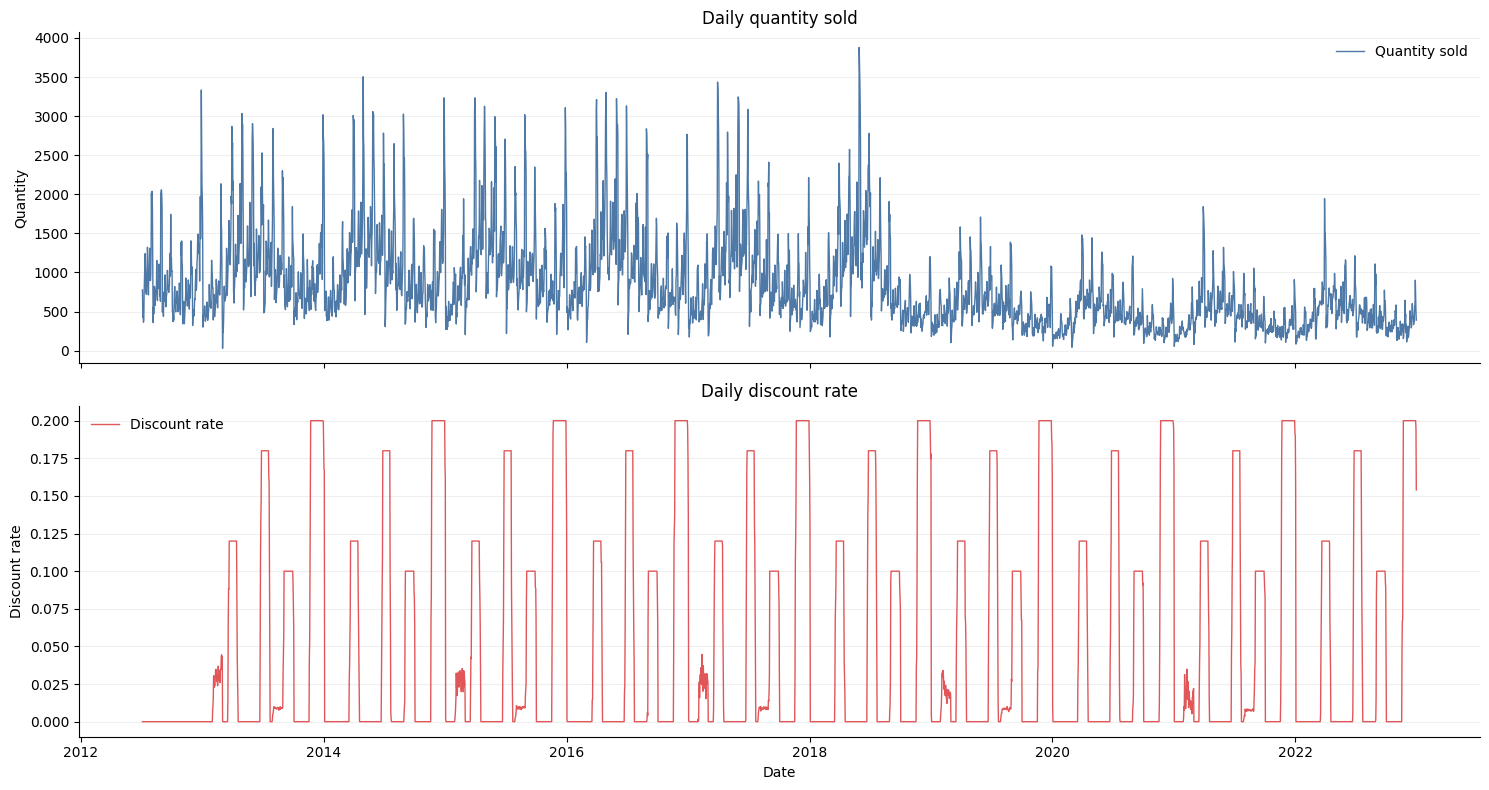

In [68]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(items_daily["Date"], items_daily["quantity_sold"], color="#4E79A7", linewidth=1.0, label="Quantity sold")
axes[0].set_title("Daily quantity sold")
axes[0].set_ylabel("Quantity")
axes[0].legend(frameon=False)

axes[1].plot(items_daily["Date"], items_daily["discount_rate"], color="#E15759", linewidth=1.0, label="Discount rate")
axes[1].set_title("Daily discount rate")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Discount rate")
axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Phân tích items/products daily aggregates

- `quantity_sold` và `unique_products_sold` có correlation cao với `Revenue`, lần lượt khoảng `0.918` và `0.911`. Điều này củng cố kết luận doanh thu chủ yếu biến động theo volume và breadth of assortment.
- `discount_amount` có correlation dương nhưng thấp hơn nhiều, khoảng `0.232`; còn `discount_rate` có correlation âm nhẹ khoảng `-0.134`. Discount có thể đi kèm hoạt động promo nhưng không phải driver tuyến tính rõ ràng của gross revenue.
- `promo_item_line_pct` cũng có correlation âm nhẹ với Revenue, khoảng `-0.111`, nên cần thận trọng khi diễn giải promo như một yếu tố tăng doanh thu.
- Category contribution cho biết doanh thu tập trung vào nhóm hàng nào; đây là cơ sở để tạo daily category-mix features.
- Top product/category contribution hữu ích cho EDA nhưng khi modeling forecast ngày tương lai nên dùng dạng lag/rolling, vì product mix cùng ngày không biết trước.

## 7. Promotion effects

Kiểm tra promo usage từ order items và active promo calendar từ `promotions`.

In [69]:
promo_daily = (
    order_item_daily_base.groupby("order_date", as_index=False)
    .agg(
        promo_item_lines=("has_promo", "sum"),
        item_lines=("product_id", "size"),
        promo_gross_revenue=("gross_revenue", lambda s: s[order_item_daily_base.loc[s.index, "has_promo"]].sum()),
        promo_discount_amount=("discount_amount", lambda s: s[order_item_daily_base.loc[s.index, "has_promo"]].sum()),
        total_discount_amount=("discount_amount", "sum"),
        total_gross_revenue=("gross_revenue", "sum"),
    )
    .rename(columns={"order_date": "Date"})
)
promo_daily["promo_item_line_pct"] = promo_daily["promo_item_lines"] / promo_daily["item_lines"] * 100
promo_daily["promo_revenue_share_pct"] = promo_daily["promo_gross_revenue"] / promo_daily["total_gross_revenue"].replace(0, np.nan) * 100
promo_daily["discount_rate"] = promo_daily["total_discount_amount"] / promo_daily["total_gross_revenue"].replace(0, np.nan)
promo_daily["has_any_promo"] = promo_daily["promo_item_lines"] > 0
promo_daily = sales[["Date", "Revenue"]].merge(promo_daily, on="Date", how="left")

promotions = pd.read_csv(DATA_DIR / "promotions.csv", parse_dates=["start_date", "end_date"])
active_promo_frames = []
for row in promotions.itertuples(index=False):
    active_promo_frames.append(
        pd.DataFrame({"Date": pd.date_range(row.start_date, row.end_date), "promo_id": row.promo_id})
    )
active_promo_calendar = pd.concat(active_promo_frames, ignore_index=True)
active_promo_daily = active_promo_calendar.groupby("Date", as_index=False).agg(active_promo_count=("promo_id", "nunique"))
promo_daily = promo_daily.merge(active_promo_daily, on="Date", how="left").fillna({"active_promo_count": 0})

promo_summary = promo_daily[["promo_item_line_pct", "promo_revenue_share_pct", "discount_rate", "active_promo_count"]].describe().T
promo_corr = promo_daily[["Revenue", "promo_item_line_pct", "promo_revenue_share_pct", "discount_rate", "active_promo_count"]].corr()["Revenue"].drop("Revenue").to_frame("corr_with_revenue")
promo_vs_no_promo = promo_daily.groupby("has_any_promo", as_index=False).agg(days=("Date", "count"), avg_revenue=("Revenue", "mean"), median_revenue=("Revenue", "median"))

display(promo_summary.round(4))
display(promo_corr.round(4))
display(promo_vs_no_promo.round(2))
display(promotions.groupby(["promo_type", "promo_channel"], as_index=False).size().sort_values("size", ascending=False))

,count,mean,std,min,25%,50%,75%,max
promo_item_line_pct,3833.0,36.8361,44.9159,0.0,0.0,0.0,100.0,100.0
promo_revenue_share_pct,3833.0,36.1338,45.2233,0.0,0.0,0.0,100.0,100.0
discount_rate,3833.0,0.0517,0.0738,0.0,0.0,0.0,0.1,0.2
active_promo_count,3833.0,0.4506,0.5080,0.0,0.0,0.0,1.0,2.0


,corr_with_revenue
promo_item_line_pct,-0.1114
promo_revenue_share_pct,-0.1103
discount_rate,-0.1342
active_promo_count,-0.0947


,has_any_promo,days,avg_revenue,median_revenue
0,False,2126,4524082.51,3819856.35
1,True,1707,3990789.21,3428606.64


,promo_type,promo_channel,size
1,percentage,all_channels,19
4,percentage,online,8
2,percentage,email,7
5,percentage,social_media,6
0,fixed,online,5
3,percentage,in_store,5


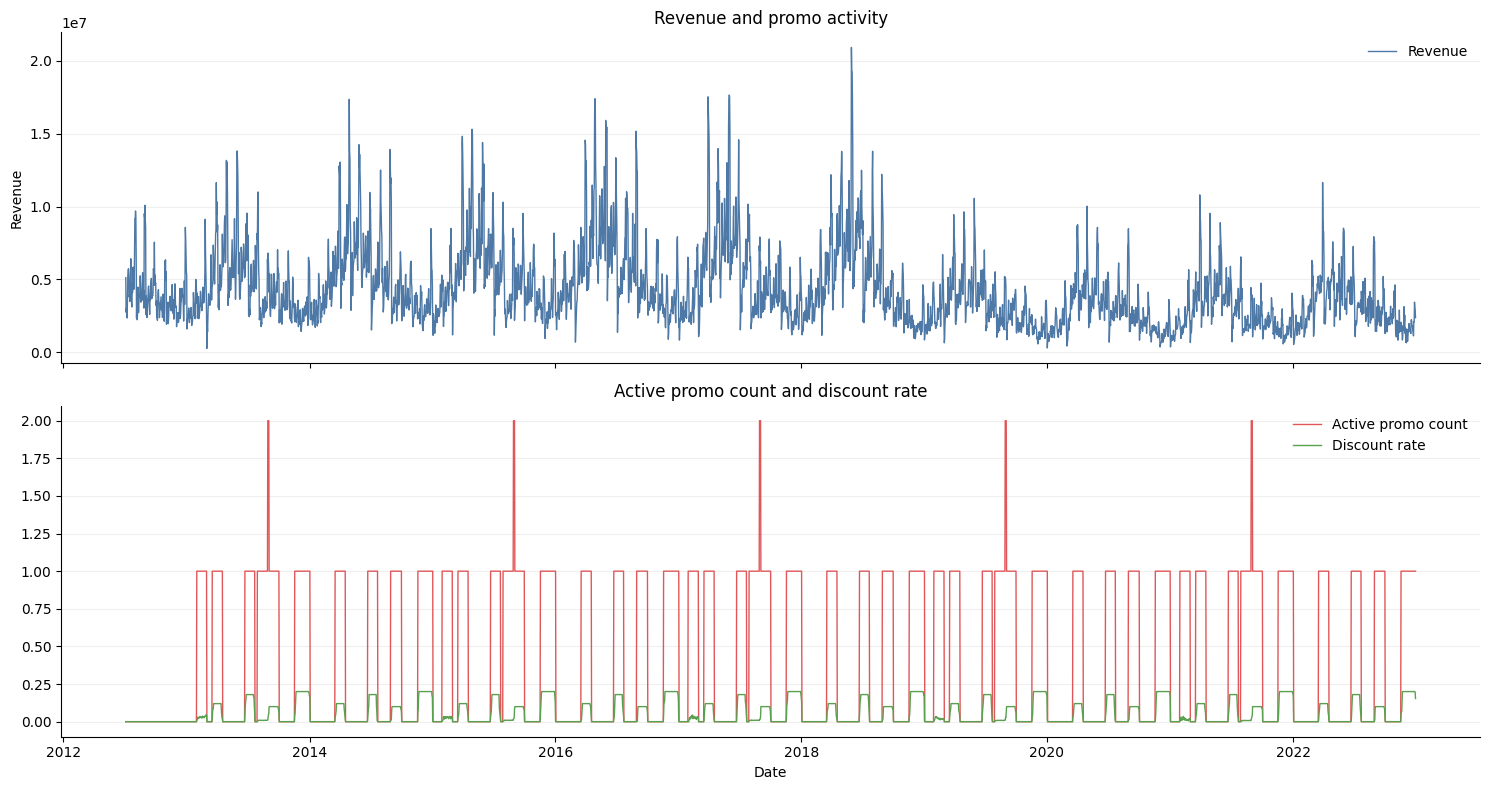

In [70]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(promo_daily["Date"], promo_daily["Revenue"], color="#4E79A7", linewidth=1.0, label="Revenue")
axes[0].set_title("Revenue and promo activity")
axes[0].set_ylabel("Revenue")
axes[0].legend(frameon=False)

axes[1].plot(promo_daily["Date"], promo_daily["active_promo_count"], color="#E15759", linewidth=1.0, label="Active promo count")
axes[1].plot(promo_daily["Date"], promo_daily["discount_rate"], color="#59A14F", linewidth=1.0, label="Discount rate")
axes[1].set_title("Active promo count and discount rate")
axes[1].set_xlabel("Date")
axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Phân tích promotion effects

- Trong dữ liệu này, `discount_rate` có correlation âm nhẹ với `Revenue` khoảng `-0.134`, và `active_promo_count` cũng âm nhẹ khoảng `-0.095`. Vì vậy promo không thể hiện rõ như một uplift driver tuyến tính của gross revenue.
- Promo vẫn có thể ảnh hưởng đến doanh thu qua cơ chế phi tuyến hoặc theo từng category/campaign, nhưng EDA tổng thể cho thấy không nên mặc định cứ có promo là revenue tăng.
- `active_promo_count` từ promotion calendar có thể là feature biết trước nếu lịch khuyến mãi được lên kế hoạch trước forecast date.
- Các biến từ actual order items như `promo_item_line_pct`, `promo_revenue_share_pct`, `discount_rate` là same-day realized signals; khi modeling cần dùng dạng lag/rolling hoặc dùng planned promo calendar thay thế.

## 8. Web traffic

Aggregate `web_traffic` theo ngày, kiểm tra correlation cùng ngày và lag correlation với Revenue.

In [71]:
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])
web_traffic["session_duration_weighted"] = web_traffic["avg_session_duration_sec"] * web_traffic["sessions"]
web_traffic["bounce_weighted"] = web_traffic["bounce_rate"] * web_traffic["sessions"]

web_daily = (
    web_traffic.groupby("date", as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        bounce_weighted=("bounce_weighted", "sum"),
        session_duration_weighted=("session_duration_weighted", "sum"),
    )
    .rename(columns={"date": "Date"})
)
web_daily["bounce_rate"] = web_daily["bounce_weighted"] / web_daily["sessions"].replace(0, np.nan)
web_daily["avg_session_duration_sec"] = web_daily["session_duration_weighted"] / web_daily["sessions"].replace(0, np.nan)
web_daily = web_daily.drop(columns=["bounce_weighted", "session_duration_weighted"])

web_revenue = sales[["Date", "Revenue"]].merge(web_daily, on="Date", how="left")
web_same_day_corr = web_revenue[["Revenue", "sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec"]].corr()["Revenue"].drop("Revenue").to_frame("same_day_corr_with_revenue")

lag_records = []
for metric in ["sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec"]:
    for lag in [1, 7, 14, 28]:
        lag_records.append(
            {
                "metric": metric,
                "lag_days": lag,
                "corr_with_revenue": web_revenue["Revenue"].corr(web_revenue[metric].shift(lag)),
            }
        )
web_lag_corr = pd.DataFrame(lag_records).sort_values(["metric", "lag_days"])

traffic_source_mix = (
    web_traffic.groupby("traffic_source", as_index=False)
    .agg(sessions=("sessions", "sum"), page_views=("page_views", "sum"), unique_visitors=("unique_visitors", "sum"))
    .assign(session_share_pct=lambda df: df["sessions"] / df["sessions"].sum() * 100)
    .sort_values("sessions", ascending=False)
)

display(web_daily.describe().T.round(2))
display(web_same_day_corr.round(4))
display(web_lag_corr.round(4))
display(traffic_source_mix.round(2))

,count,mean,min,25%,50%,75%,max,std
Date,3652,2017-12-31 12:00:00,2013-01-01 00:00:00,2015-07-02 18:00:00,2017-12-31 12:00:00,2020-07-01 06:00:00,2022-12-31 00:00:00,NaN
sessions,3652.0,25041.768072,7973.0,17099.25,23633.5,31782.75,50947.0,9422.609335
unique_visitors,3652.0,19031.404436,6136.0,12915.0,17924.0,24191.75,40430.0,7237.953062
page_views,3652.0,108615.224535,30451.0,72982.0,101010.5,138086.0,275560.0,44472.055524
bounce_rate,3652.0,0.004487,0.0032,0.003847,0.00445,0.00516,0.0058,0.000753
avg_session_duration_sec,3652.0,210.283242,100.1,156.7,209.2,266.2,319.9,63.771711


,same_day_corr_with_revenue
sessions,0.3211
unique_visitors,0.3188
page_views,0.3016
bounce_rate,-0.0206
avg_session_duration_sec,-0.0256


,metric,lag_days,corr_with_revenue
16,avg_session_duration_sec,1,-0.0214
17,avg_session_duration_sec,7,-0.0069
18,avg_session_duration_sec,14,-0.0035
19,avg_session_duration_sec,28,0.0052
12,bounce_rate,1,-0.0173
13,bounce_rate,7,-0.0146
14,bounce_rate,14,-0.0235
15,bounce_rate,28,-0.0214
8,page_views,1,0.3055
9,page_views,7,0.2865


,traffic_source,sessions,page_views,unique_visitors,session_share_pct
2,organic_search,27196976,117606452,20625107,29.74
3,paid_search,19598271,85079551,14922386,21.43
5,social_media,15816226,68072140,12048065,17.29
1,email_campaign,12792670,55477636,9700462,13.99
4,referral,9476845,41655659,7220019,10.36
0,direct,6571549,28771362,4986650,7.19


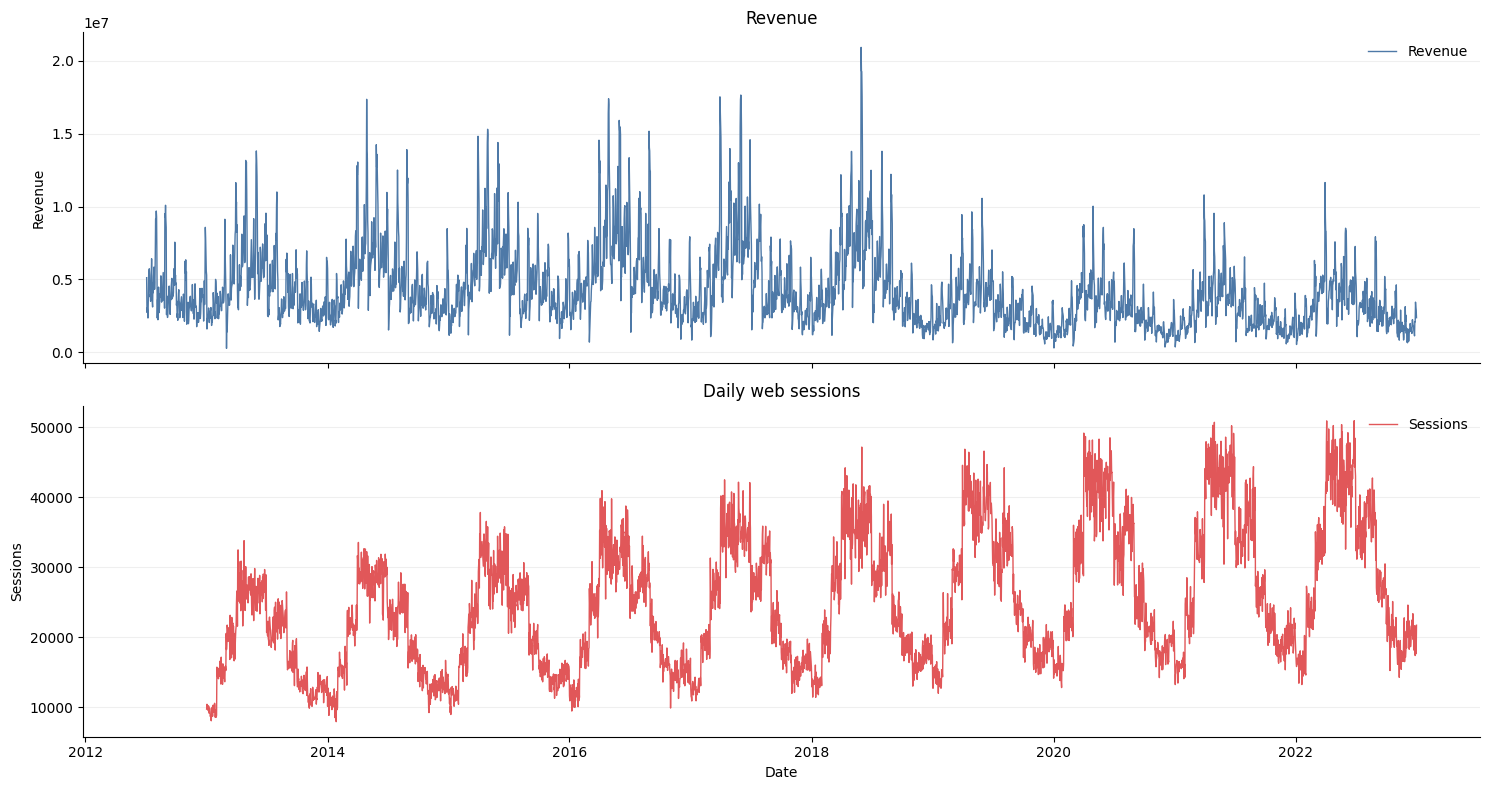

In [72]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(web_revenue["Date"], web_revenue["Revenue"], color="#4E79A7", linewidth=1.0, label="Revenue")
axes[0].set_title("Revenue")
axes[0].set_ylabel("Revenue")
axes[0].legend(frameon=False)

axes[1].plot(web_revenue["Date"], web_revenue["sessions"], color="#E15759", linewidth=1.0, label="Sessions")
axes[1].set_title("Daily web sessions")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Sessions")
axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Phân tích web traffic

- Web traffic có tương quan dương vừa phải với Revenue: `sessions` khoảng `0.321`, `unique_visitors` khoảng `0.319`, `page_views` khoảng `0.302`.
- `bounce_rate` và `avg_session_duration_sec` gần như không có tương quan tuyến tính với Revenue trong daily aggregate, lần lượt khoảng `-0.021` và `-0.026`.
- Web traffic là nhóm feature đáng kiểm tra vì có thể đi trước hoặc đồng biến với nhu cầu mua hàng, nhưng tín hiệu không mạnh bằng orders/items volume.
- Same-day traffic có nguy cơ không biết trước khi forecast, nên dùng chủ yếu cho EDA. Với modeling nên ưu tiên `sessions_lag_1`, `sessions_lag_7`, rolling mean 7/28 ngày, hoặc planned marketing traffic nếu có.
- Source mix traffic có thể giúp phân biệt organic/direct/referral/paid behavior, nhưng cũng nên dùng dạng lag/rolling.

## 9. Inventory

Aggregate inventory theo tháng và so sánh với monthly revenue. Vì inventory là product-month snapshot, same-month feature có thể leakage nếu snapshot được tạo cuối tháng; modeling nên ưu tiên lagged monthly inventory.

In [73]:
inventory = pd.read_csv(DATA_DIR / "inventory.csv", parse_dates=["snapshot_date"])

inventory_monthly = (
    inventory.groupby(["year", "month"], as_index=False)
    .agg(
        products_tracked=("product_id", "nunique"),
        stock_on_hand=("stock_on_hand", "sum"),
        units_received=("units_received", "sum"),
        units_sold_inventory=("units_sold", "sum"),
        stockout_days=("stockout_days", "sum"),
        avg_days_of_supply=("days_of_supply", "mean"),
        avg_fill_rate=("fill_rate", "mean"),
        stockout_product_pct=("stockout_flag", "mean"),
        overstock_product_pct=("overstock_flag", "mean"),
        reorder_product_pct=("reorder_flag", "mean"),
        avg_sell_through_rate=("sell_through_rate", "mean"),
    )
)
inventory_monthly["year_month"] = pd.to_datetime(inventory_monthly["year"].astype(str) + "-" + inventory_monthly["month"].astype(str) + "-01")

sales_monthly = (
    sales.assign(year=lambda df: df["Date"].dt.year, month=lambda df: df["Date"].dt.month)
    .groupby(["year", "month"], as_index=False)
    .agg(monthly_revenue=("Revenue", "sum"), avg_daily_revenue=("Revenue", "mean"), days=("Date", "count"))
)

inventory_revenue_monthly = sales_monthly.merge(inventory_monthly, on=["year", "month"], how="left")
inventory_metrics = ["stock_on_hand", "units_received", "units_sold_inventory", "stockout_days", "avg_fill_rate", "stockout_product_pct", "avg_sell_through_rate"]
inventory_corr = inventory_revenue_monthly[["monthly_revenue"] + inventory_metrics].corr()["monthly_revenue"].drop("monthly_revenue").to_frame("same_month_corr_with_monthly_revenue")

display(inventory_monthly.tail(12).round(4))
display(inventory_corr.round(4))

,year,month,products_tracked,stock_on_hand,units_received,units_sold_inventory,stockout_days,avg_days_of_supply,avg_fill_rate,stockout_product_pct,overstock_product_pct,reorder_product_pct,avg_sell_through_rate,year_month
114,2022,1,388,100332,2607,2305,357,2078.4840,0.9693,0.5825,0.8196,0.0,0.1101,2022-01-01
115,2022,2,426,106405,3713,3270,456,1637.3728,0.9643,0.6808,0.7488,0.0,0.1367,2022-02-01
116,2022,3,474,111674,5911,5096,529,1535.0926,0.9628,0.6814,0.7278,0.0,0.1522,2022-03-01
117,2022,4,496,116977,7443,6360,626,1340.9212,0.9579,0.7016,0.6815,0.0,0.1740,2022-04-01
118,2022,5,485,116939,6401,5509,513,1576.8320,0.9647,0.6619,0.7134,0.0,0.1584,2022-05-01
119,2022,6,464,109700,6693,5759,502,1327.9164,0.9639,0.6746,0.6961,0.0,0.1583,2022-06-01
120,2022,7,410,102083,4746,4123,431,1347.8878,0.9650,0.6927,0.7488,0.0,0.1393,2022-07-01
121,2022,8,461,104884,5499,4772,481,1296.2913,0.9652,0.6529,0.7267,0.0,0.1442,2022-08-01
122,2022,9,419,107309,3868,3360,415,1937.0587,0.9670,0.6420,0.8115,0.0,0.1187,2022-09-01
123,2022,10,409,104255,3309,2908,469,1992.5443,0.9618,0.6553,0.8582,0.0,0.1145,2022-10-01


,same_month_corr_with_monthly_revenue
stock_on_hand,-0.1821
units_received,0.8801
units_sold_inventory,0.8807
stockout_days,0.6490
avg_fill_rate,-0.4324
stockout_product_pct,0.1930
avg_sell_through_rate,0.6474


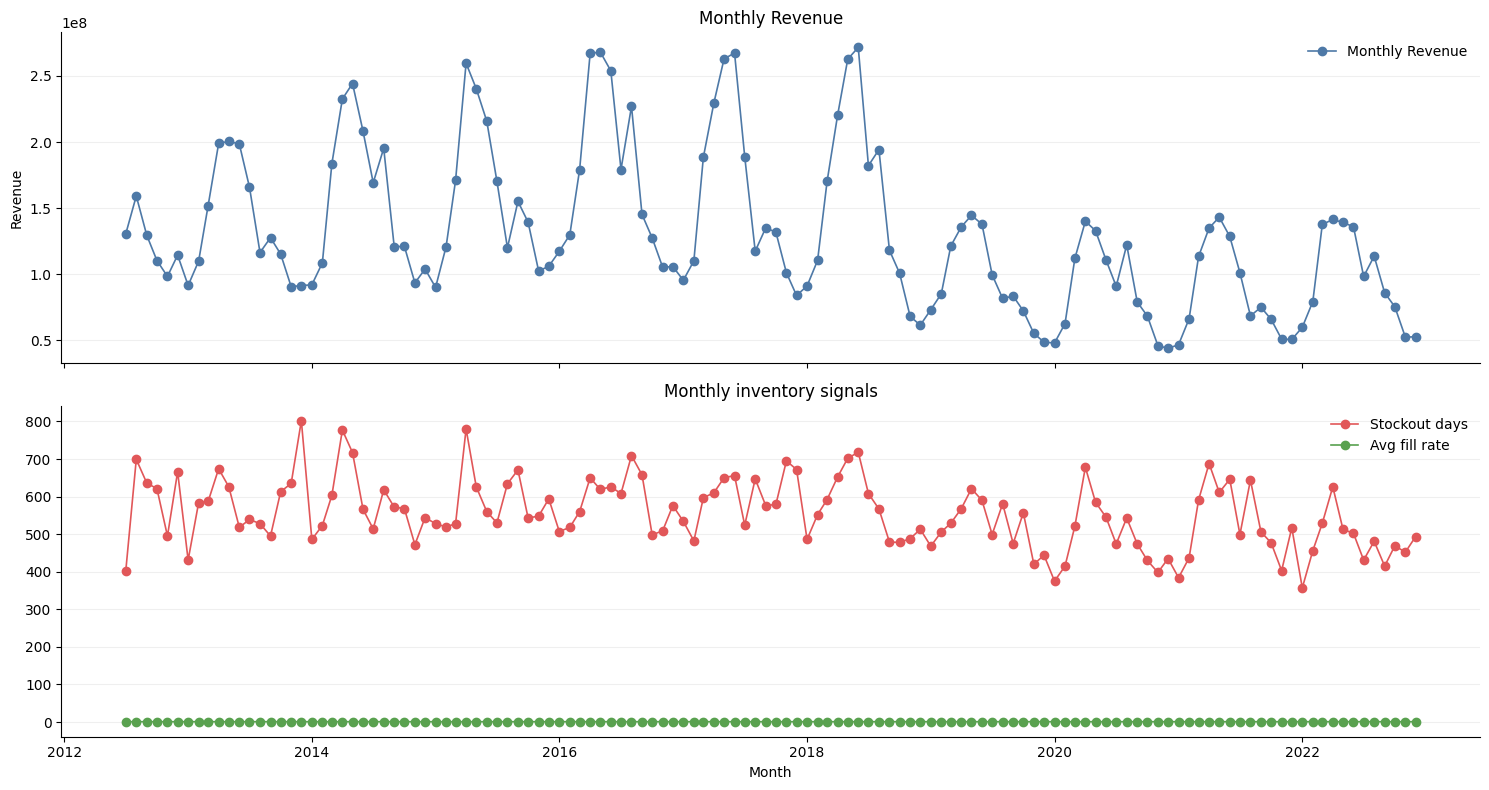

In [74]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(inventory_revenue_monthly["year_month"], inventory_revenue_monthly["monthly_revenue"], color="#4E79A7", marker="o", linewidth=1.2, label="Monthly Revenue")
axes[0].set_title("Monthly Revenue")
axes[0].set_ylabel("Revenue")
axes[0].legend(frameon=False)

axes[1].plot(inventory_revenue_monthly["year_month"], inventory_revenue_monthly["stockout_days"], color="#E15759", marker="o", linewidth=1.2, label="Stockout days")
axes[1].plot(inventory_revenue_monthly["year_month"], inventory_revenue_monthly["avg_fill_rate"], color="#59A14F", marker="o", linewidth=1.2, label="Avg fill rate")
axes[1].set_title("Monthly inventory signals")
axes[1].set_xlabel("Month")
axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Phân tích inventory

- Inventory có tương quan đáng chú ý ở mức monthly: `units_received` và `units_sold_inventory` tương quan với monthly revenue khoảng `0.88`; `stockout_days` khoảng `0.649`; `avg_sell_through_rate` khoảng `0.647`.
- `avg_fill_rate` tương quan âm khoảng `-0.432`, có thể phản ánh giai đoạn demand cao làm fill rate giảm, nhưng không nên diễn giải nhân quả trực tiếp.
- Inventory có thể phản ánh khả năng cung ứng và demand pressure: stockout cao có thể vừa là dấu hiệu bán tốt vừa là giới hạn nguồn cung.
- Vì bảng này ở grain product-month, không nên join trực tiếp vào daily table như daily feature. Cách hợp lý là aggregate theo tháng rồi dùng lagged inventory cho dự báo.
- Same-month inventory chỉ nên dùng cho EDA hoặc nếu xác nhận đây là snapshot đầu kỳ/biết trước. Nếu snapshot cuối tháng, dùng same-month sẽ leakage.

## 10. EDA findings and feature candidates

Tổng hợp các nhóm feature candidate sau EDA, đánh giá usefulness và leakage risk.

In [75]:
feature_candidates = pd.DataFrame(
    [
        {"feature_group": "Calendar", "usefulness": "High", "leakage_risk": "Low", "modeling_usage": "Use raw/future-known", "notes": "month, quarter, day_of_week, is_weekend, is_month_end_window, days_to_month_end."},
        {"feature_group": "Tết calendar", "usefulness": "Medium", "leakage_risk": "Low", "modeling_usage": "Use raw/future-known", "notes": "Dataset shows Tết as low-season, but horizon includes Tết 2023/2024."},
        {"feature_group": "Revenue lags/rolling", "usefulness": "High", "leakage_risk": "Low", "modeling_usage": "Use lag/rolling only", "notes": "lag 1/7/14/28, rolling mean/std 7/28/90."},
        {"feature_group": "Orders daily aggregates", "usefulness": "High for EDA; Medium for forecast", "leakage_risk": "High if same-day", "modeling_usage": "Use lag/rolling", "notes": "order_count, unique_customers, status/source/device/payment mix."},
        {"feature_group": "Items/products aggregates", "usefulness": "High for EDA; Medium for forecast", "leakage_risk": "High if same-day", "modeling_usage": "Use lag/rolling", "notes": "quantity_sold, unique_products_sold, category mix, discount_rate."},
        {"feature_group": "Promotion calendar", "usefulness": "Medium", "leakage_risk": "Low if planned", "modeling_usage": "Use active planned promo features", "notes": "active_promo_count can be future-known if campaign calendar is planned."},
        {"feature_group": "Actual promo usage", "usefulness": "Medium", "leakage_risk": "High if same-day", "modeling_usage": "Use lag/rolling", "notes": "promo_item_line_pct and discount_rate are realized transaction signals."},
        {"feature_group": "Web traffic", "usefulness": "Medium to High", "leakage_risk": "High if same-day", "modeling_usage": "Use lag/rolling", "notes": "sessions, visitors, page_views, source mix; test lag correlations."},
        {"feature_group": "Inventory", "usefulness": "Medium", "leakage_risk": "Medium/High if same-month", "modeling_usage": "Use monthly lag", "notes": "product-month operational context; avoid same-month if snapshot timing is unknown."},
        {"feature_group": "Shipments/returns/reviews", "usefulness": "Low for this target", "leakage_risk": "High", "modeling_usage": "Exclude by default", "notes": "Post-order signals; not needed for gross daily revenue forecast."},
    ]
)

display(feature_candidates)

,feature_group,usefulness,leakage_risk,modeling_usage,notes
0,Calendar,High,Low,Use raw/future-known,"month, quarter, day_of_week, is_weekend, is_mo..."
1,Tết calendar,Medium,Low,Use raw/future-known,"Dataset shows Tết as low-season, but horizon i..."
2,Revenue lags/rolling,High,Low,Use lag/rolling only,"lag 1/7/14/28, rolling mean/std 7/28/90."
3,Orders daily aggregates,High for EDA; Medium for forecast,High if same-day,Use lag/rolling,"order_count, unique_customers, status/source/d..."
4,Items/products aggregates,High for EDA; Medium for forecast,High if same-day,Use lag/rolling,"quantity_sold, unique_products_sold, category ..."
5,Promotion calendar,Medium,Low if planned,Use active planned promo features,active_promo_count can be future-known if camp...
6,Actual promo usage,Medium,High if same-day,Use lag/rolling,promo_item_line_pct and discount_rate are real...
7,Web traffic,Medium to High,High if same-day,Use lag/rolling,"sessions, visitors, page_views, source mix; te..."
8,Inventory,Medium,Medium/High if same-month,Use monthly lag,product-month operational context; avoid same-...
9,Shipments/returns/reviews,Low for this target,High,Exclude by default,Post-order signals; not needed for gross daily...


### EDA findings summary

- Target `sales.Revenue` là gross revenue trên all orders và có daily calendar liên tục.
- Seasonality mạnh nhất hiện nằm ở `month/quarter`, đặc biệt Apr-May-Jun, và hiệu ứng cuối tháng.
- Tết trong dữ liệu này không phải peak season; nên dùng như calendar feature nhưng không áp đặt uplift thủ công.
- Margin có seasonality theo tháng rõ rệt; August và December có nhiều ngày margin âm, nhưng target forecast vẫn là Revenue.
- Orders/items/web traffic là nhóm feature giải thích tốt trong EDA, nhưng nếu dùng cho forecast cần chuyển sang lag/rolling để tránh leakage.
- Inventory có thể hữu ích ở mức monthly context, nhưng cần dùng lagged monthly features vì snapshot timing chưa chắc là future-known.